**NOTE:** This version's dataset has been limited to the North Americas (USA + Canada). Top performing method is SBERT + TFIDF on models LightGBM and XGBoost in the validation set. 

# Libraries

This section imports the Python libraries used for data loading, preprocessing, visualization, feature engineering, and later machine learning experiments.

In [1]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from IPython.display import display

# Data Loading

The study uses three datasets:

1. `data_jobs.csv` as the main international job postings dataset
2. `FIES2015 - LFSJAN16 CSV - Cleaned.csv` as the Philippine local dataset for contextual validation
3. `world_bank_data_2025.csv` as the country-level macroeconomic dataset

At this stage, the datasets are loaded and inspected to confirm that they were read correctly.

In [2]:
# Main international job postings dataset
jobs = pd.read_csv("data_jobs.csv")

# Philippine local dataset (reserved for later external validation)
lfs = pd.read_csv("FIES2015 - LFSJAN16 CSV - Cleaned.csv", low_memory=False)

# World Bank country-level context data
econ = pd.read_csv("world_bank_data_2025.csv")

print("jobs shape:", jobs.shape)
print("lfs shape:", lfs.shape)
print("econ shape:", econ.shape)

display(jobs.head())

jobs shape: (785741, 17)
lfs shape: (207212, 154)
econ shape: (3472, 16)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [3]:
print("Jobs columns:")
display(pd.Series(jobs.columns))

print("\nJobs info:")
jobs.info()

Jobs columns:


0           job_title_short
1                 job_title
2              job_location
3                   job_via
4         job_schedule_type
5        job_work_from_home
6           search_location
7           job_posted_date
8     job_no_degree_mention
9      job_health_insurance
10              job_country
11              salary_rate
12          salary_year_avg
13          salary_hour_avg
14             company_name
15               job_skills
16          job_type_skills
dtype: object


Jobs info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           7

In [4]:
print("LFS columns:")
display(pd.Series(lfs.columns[:30]))

print("\nWorld Bank columns:")
display(pd.Series(econ.columns))

LFS columns:


0                id
1            person
2            w_regn
3          other_id
4             rfact
5           pop_adj
6               urb
7              tstr
8              tpsu
9             pcinc
10             rstr
11             rpsu
12            fsize
13         agri_sal
14      nonagri_sal
15            wages
16         netshare
17      cash_abroad
18    cash_domestic
19      rentals_rec
20         interest
21          pension
22        dividends
23     other_source
24      net_receipt
25            regft
26          net_cfg
27          net_lpr
28         net_fish
29          net_for
dtype: object


World Bank columns:


0                        country_name
1                          country_id
2                                year
3                   Inflation (CPI %)
4                   GDP (Current USD)
5        GDP per Capita (Current USD)
6               Unemployment Rate (%)
7             Interest Rate (Real, %)
8         Inflation (GDP Deflator, %)
9               GDP Growth (% Annual)
10    Current Account Balance (% GDP)
11      Government Expense (% of GDP)
12      Government Revenue (% of GDP)
13             Tax Revenue (% of GDP)
14        Gross National Income (USD)
15             Public Debt (% of GDP)
dtype: object

# Data Preprocessing

This section prepares the main job postings dataset for analysis and later modeling.

The preprocessing pipeline includes:

- country standardization
- integration of World Bank country-level features
- salary normalization
- outlier removal
- log transformation of salary
- skill cleaning and parsing
- engineering of skill-category count features
- regional grouping
- filtering of rare job titles

In [5]:
# -------------------------
# COUNTRY STANDARDIZATION
# -------------------------
country_map = {
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Iran": "Iran, Islamic Rep.",
    "Venezuela": "Venezuela, RB",
    "Slovakia": "Slovak Republic",
    "Hong Kong": "Hong Kong SAR, China",
    "Macedonia (FYROM)": "North Macedonia",
    "Palestine": "West Bank and Gaza",
    "Laos": "Lao PDR",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Turkiye",
    "Yemen": "Yemen, Rep.",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Bahamas": "Bahamas, The",
    "Brunei": "Brunei Darussalam",
    "Congo, Democratic Republic of the": "Congo, Dem. Rep.",
    "Curaçao": "Curacao",
    "Gambia": "Gambia, The",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Taiwan": "Taiwan, China",
    "U.S. Virgin Islands": "Virgin Islands (U.S.)"
}

In [6]:
# -------------------------
# WORLD BANK 2023 FEATURES
# -------------------------
econ_2023 = econ[econ["year"] == 2023].copy()

econ_2023 = econ_2023[[
    "country_name",
    "GDP per Capita (Current USD)",
    "GDP (Current USD)",
    "Unemployment Rate (%)",
    "Inflation (CPI %)",
    "GDP Growth (% Annual)"
]]

# interest rate, gross national income (USD)

econ_2023.columns = [
    "country",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth"
]

display(econ_2023.head())

,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
13,Aruba,33984.790620,3.648573e+09,NaN,NaN,4.263719
29,Afghanistan,415.707417,1.723305e+10,13.991,-4.644709,2.710887
45,Angola,2308.159767,8.482465e+10,14.537,13.644102,1.001289
61,Albania,8575.171134,2.354718e+10,10.108,4.759764,3.936625
77,Andorra,46812.448449,3.785067e+09,NaN,NaN,2.583555


Only the columns directly relevant to salary prediction, skill representation, and job context are retained from the main dataset.

In [7]:
# -------------------------
# KEEP USEFUL COLUMNS
# -------------------------
wanted_cols = [
    "job_title_short",
    "job_title",
    "job_location",
    "job_via",
    "job_schedule_type",
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
    "job_country",
    "salary_rate",
    "salary_year_avg",
    "salary_hour_avg",
    "company_name",
    "job_skills",
    "job_type_skills"
]

existing_cols = [c for c in wanted_cols if c in jobs.columns]

jobs_model = jobs[existing_cols].copy()

# standardize country names
jobs_model["job_country"] = jobs_model["job_country"].replace(country_map)

# filter to North America
jobs_model = jobs_model[jobs_model["job_country"].isin([
    "United States", "Canada"
])].copy()

print("Shape after NA filter:", jobs_model.shape)

# merge economic features
jobs_model = jobs_model.merge(
    econ_2023,
    left_on="job_country",
    right_on="country",
    how="left"
)

# fill numeric macroeconomic missings with median
for col in ["gdp_per_capita", "gdp", "unemployment", "inflation", "gdp_growth"]:
    if col in jobs_model.columns:
        jobs_model[col] = jobs_model[col].fillna(jobs_model[col].median())

print("jobs_model shape after merge:", jobs_model.shape)
display(jobs_model.head())

Shape after NA filter: (222321, 15)
jobs_model shape after merge: (222321, 21)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,salary_hour_avg,company_name,job_skills,job_type_skills,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,False,False,United States,NaN,...,NaN,Boehringer Ingelheim,NaN,NaN,United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
1,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,True,False,United States,NaN,...,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
2,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,False,False,United States,NaN,...,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
3,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,False,False,United States,NaN,...,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
4,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,False,False,United States,NaN,...,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556


In [8]:
print(jobs_model["job_country"].value_counts())

job_country
United States    206292
Canada            16029
Name: count, dtype: int64


A unified annual salary variable is created. If annual salary is unavailable, hourly salary is converted using a 40-hour work week and 52 weeks per year.

In [9]:
# -------------------------
# TARGET SALARY
# -------------------------
def get_salary(row):
    if pd.notna(row.get("salary_year_avg")):
        return row["salary_year_avg"]
    if pd.notna(row.get("salary_hour_avg")):
        return row["salary_hour_avg"] * 40 * 52
    return np.nan

jobs_model["salary"] = jobs_model.apply(get_salary, axis=1)
jobs_model = jobs_model.dropna(subset=["salary"]).copy()

print("Shape after removing missing salaries:", jobs_model.shape)

Shape after removing missing salaries: (25685, 22)


In [10]:
# remove salary outliers (IQR)
Q1 = jobs_model["salary"].quantile(0.25)
Q3 = jobs_model["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

jobs_model = jobs_model[
    (jobs_model["salary"] >= lower) &
    (jobs_model["salary"] <= upper)
].copy()

jobs_model["salary_log"] = np.log1p(jobs_model["salary"])

print("Shape after outlier removal:", jobs_model.shape)
print("Salary summary:")
display(jobs_model["salary"].describe())

Shape after outlier removal: (25176, 23)
Salary summary:


count     25176.000000
mean     112131.955287
std       42085.044017
min       16640.000000
25%       82500.000000
50%      110219.203491
75%      140000.000000
max      231000.000000
Name: salary, dtype: float64

In [11]:
# -------------------------
# ADD ENGINEERED ECON FEATURES
# -------------------------
jobs_model["gdp_per_capita_log"] = np.log1p(jobs_model["gdp_per_capita"])
jobs_model["gdp_log"] = np.log1p(jobs_model["gdp"])
jobs_model["labor_market_tightness"] = 1 - jobs_model["unemployment"]
jobs_model["real_gdp_per_capita"] = jobs_model["gdp_per_capita"] / (1 + jobs_model["inflation"] / 100)

The `job_skills` column is cleaned and converted into a standardized list of lowercase skills for each posting.

In [12]:
# -------------------------
# CLEAN SKILLS
# -------------------------
def clean_skills(x):
    if isinstance(x, list):
        all_items = []
        for item in x:
            text = str(item).strip().strip("'\"[]")
            parts = re.split(r",\s*", text)
            all_items.extend(parts)
        return [s.strip().strip("'\" ").lower() for s in all_items if s.strip()]
    
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return clean_skills(parsed)
        except:
            pass
        x_clean = x.strip().strip("[]")
        parts = re.split(r",\s*", x_clean)
        return [s.strip().strip("'\" ").lower() for s in parts if s.strip()]
    
    return []

jobs_model["skills_list"] = jobs_model["job_skills"].apply(clean_skills)
jobs_model["skills_list"] = jobs_model["skills_list"].apply(lambda x: list(dict.fromkeys(x)))
jobs_model["skill_count"] = jobs_model["skills_list"].apply(len)

display(jobs_model[["job_skills", "skills_list", "skill_count"]].head(10))

,job_skills,skills_list,skill_count
18,"['sql', 'sql server']","[sql, sql server]",2
20,"['python', 'java', 'aws', 'databricks', 'spark']","[python, java, aws, databricks, spark]",5
34,"['sql', 'python']","[sql, python]",2
39,"['sql', 'r', 'python', 'express']","[sql, r, python, express]",4
40,"['python', 'r', 'alteryx', 'tableau']","[python, r, alteryx, tableau]",4
45,"['r', 'python', 'sql', 't-sql', 'hadoop', 'spa...","[r, python, sql, t-sql, hadoop, spark, tableau]",7
61,"['golang', 'scala', 'python', 'java', 'hadoop'...","[golang, scala, python, java, hadoop, spark]",6
73,"['excel', 'powerpoint']","[excel, powerpoint]",2
101,"['sql', 'python', 'java', 'mysql', 'postgresql...","[sql, python, java, mysql, postgresql, aws, gc...",8
102,"['r', 'electron']","[r, electron]",2


The `job_type_skills` column contains grouped skill categories. These are parsed to create count-based features for skill families such as analyst tools, cloud tools, databases, and programming languages.

In [13]:
# -------------------------
# PARSE job_type_skills
# -------------------------
def parse_skill_dict(x):
    if isinstance(x, dict):
        return x
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return {}
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            return parsed if isinstance(parsed, dict) else {}
        except:
            return {}
    return {}

jobs_model["job_type_skills_parsed"] = jobs_model["job_type_skills"].apply(parse_skill_dict)

skill_type_categories = [
    "analyst_tools", "cloud", "libraries", "databases", "programming",
    "other", "webframeworks", "os", "async", "sync"
]

for cat in skill_type_categories:
    jobs_model[f"{cat}_count"] = jobs_model["job_type_skills_parsed"].apply(
        lambda d: len(d.get(cat, [])) if isinstance(d, dict) else 0
    )

jobs_model["num_skill_categories"] = jobs_model["job_type_skills_parsed"].apply(
    lambda d: len([k for k, v in d.items() if isinstance(v, list) and len(v) > 0]) if isinstance(d, dict) else 0
)

display(
    jobs_model[
        ["job_type_skills", "job_type_skills_parsed"] +
        [f"{cat}_count" for cat in skill_type_categories] +
        ["num_skill_categories"]
    ].head(10)
)

,job_type_skills,job_type_skills_parsed,analyst_tools_count,cloud_count,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories
18,"{'databases': ['sql server'], 'programming': [...","{'databases': ['sql server'], 'programming': [...",0,0,0,1,1,0,0,0,0,0,2
20,"{'cloud': ['aws', 'databricks'], 'libraries': ...","{'cloud': ['aws', 'databricks'], 'libraries': ...",0,2,1,0,2,0,0,0,0,0,3
34,"{'programming': ['sql', 'python']}","{'programming': ['sql', 'python']}",0,0,0,0,2,0,0,0,0,0,1
39,"{'programming': ['sql', 'r', 'python'], 'webfr...","{'programming': ['sql', 'r', 'python'], 'webfr...",0,0,0,0,3,0,1,0,0,0,2
40,"{'analyst_tools': ['alteryx', 'tableau'], 'pro...","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",2,0,0,0,2,0,0,0,0,0,2
45,"{'analyst_tools': ['tableau'], 'libraries': ['...","{'analyst_tools': ['tableau'], 'libraries': ['...",1,0,2,0,4,0,0,0,0,0,3
61,"{'libraries': ['hadoop', 'spark'], 'programmin...","{'libraries': ['hadoop', 'spark'], 'programmin...",0,0,2,0,4,0,0,0,0,0,2
73,"{'analyst_tools': ['excel', 'powerpoint']}","{'analyst_tools': ['excel', 'powerpoint']}",2,0,0,0,0,0,0,0,0,0,1
101,"{'cloud': ['aws', 'gcp'], 'databases': ['mysql...","{'cloud': ['aws', 'gcp'], 'databases': ['mysql...",0,2,1,2,3,0,0,0,0,0,4
102,"{'libraries': ['electron'], 'programming': ['r']}","{'libraries': ['electron'], 'programming': ['r']}",0,0,1,0,1,0,0,0,0,0,2


In [14]:
# -------------------------
# REGION GROUPING
# -------------------------
region_map = {
    "United States": "NA", "Canada": "NA",
    "Mexico": "LATAM", "Costa Rica": "LATAM", "Guatemala": "LATAM", "Panama": "LATAM",
    "Brazil": "LATAM", "Argentina": "LATAM", "Chile": "LATAM", "Peru": "LATAM",
    "United Kingdom": "EU", "Germany": "EU", "France": "EU", "Spain": "EU", "Italy": "EU",
    "Belgium": "EU", "Denmark": "EU", "Poland": "EU", "Portugal": "EU", "Sweden": "EU",
    "Netherlands": "EU", "Ireland": "EU", "Austria": "EU", "Romania": "EU", "Finland": "EU",
    "Switzerland": "EU", "Norway": "EU",
    "Philippines": "SEA", "Singapore": "SEA", "Indonesia": "SEA", "Malaysia": "SEA",
    "Thailand": "SEA", "Viet Nam": "SEA", "Brunei Darussalam": "SEA",
    "Japan": "EAST_ASIA", "Korea, Rep.": "EAST_ASIA", "Taiwan, China": "EAST_ASIA", "China": "EAST_ASIA",
    "India": "SOUTH_ASIA", "Pakistan": "SOUTH_ASIA", "Bangladesh": "SOUTH_ASIA",
    "United Arab Emirates": "ME", "Israel": "ME", "Jordan": "ME", "Turkiye": "ME",
    "South Africa": "AFRICA", "Nigeria": "AFRICA", "Kenya": "AFRICA", "Morocco": "AFRICA", "Egypt, Arab Rep.": "AFRICA",
    "Australia": "OCEANIA", "New Zealand": "OCEANIA"
}

jobs_model["region"] = jobs_model["job_country"].map(region_map).fillna("OTHER")

In [15]:
# -------------------------
# FILTER RARE TITLES
# -------------------------
title_counts = jobs_model["job_title_short"].value_counts()
common_titles = title_counts[title_counts >= 100].index

jobs_model = jobs_model[jobs_model["job_title_short"].isin(common_titles)].copy()

print("Final modeling dataframe shape:", jobs_model.shape)
display(jobs_model.head())

Final modeling dataframe shape: (25134, 42)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories,region
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,1,1,0,0,0,0,0,2,NA
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,1,0,2,0,0,0,0,0,3,NA
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,1,NA
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,0,0,3,0,1,0,0,0,2,NA
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,2,NA


# Exploratory Data Analysis (EDA)

Before building predictive models, exploratory data analysis is conducted to verify the correctness of preprocessing and to better understand the structure of the dataset.

The EDA focuses on:
- dataset structure and missingness
- salary distribution before and after log transformation
- job title distribution
- skill count distribution
- most common technical skills
- region distribution
- relationships between selected features and salary

This step helps assess whether preprocessing and feature engineering produced meaningful data for modeling.

In [16]:
print("Dataset shape:", jobs_model.shape)

print("\nColumns:")
display(pd.Series(jobs_model.columns))

print("\nMissing values:")
display(jobs_model.isna().sum().sort_values(ascending=False).head(20))

Dataset shape: (25134, 42)

Columns:


0            job_title_short
1                  job_title
2               job_location
3                    job_via
4          job_schedule_type
5         job_work_from_home
6      job_no_degree_mention
7       job_health_insurance
8                job_country
9                salary_rate
10           salary_year_avg
11           salary_hour_avg
12              company_name
13                job_skills
14           job_type_skills
15                   country
16            gdp_per_capita
17                       gdp
18              unemployment
19                 inflation
20                gdp_growth
21                    salary
22                salary_log
23        gdp_per_capita_log
24                   gdp_log
25    labor_market_tightness
26       real_gdp_per_capita
27               skills_list
28               skill_count
29    job_type_skills_parsed
30       analyst_tools_count
31               cloud_count
32           libraries_count
33           databases_count
34         pro


Missing values:


salary_hour_avg          15755
salary_year_avg           9379
job_type_skills           2529
job_skills                2529
job_location               275
job_schedule_type          130
job_via                      7
job_title_short              0
job_title                    0
job_work_from_home           0
salary_rate                  0
job_country                  0
job_health_insurance         0
job_no_degree_mention        0
company_name                 0
country                      0
gdp_per_capita               0
gdp                          0
unemployment                 0
inflation                    0
dtype: int64

The following plots examine the salary distribution before and after log transformation. This helps confirm whether the target variable has been appropriately stabilized for later modeling.

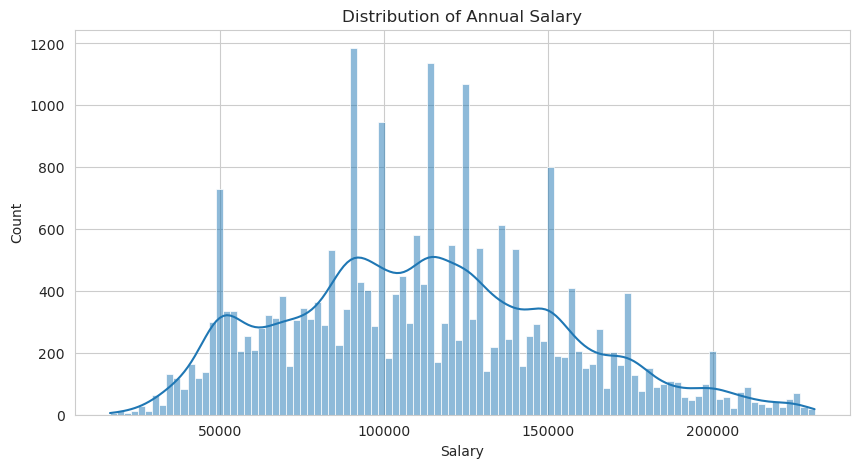

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(jobs_model["salary"], bins=100, kde=True)
plt.title("Distribution of Annual Salary")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

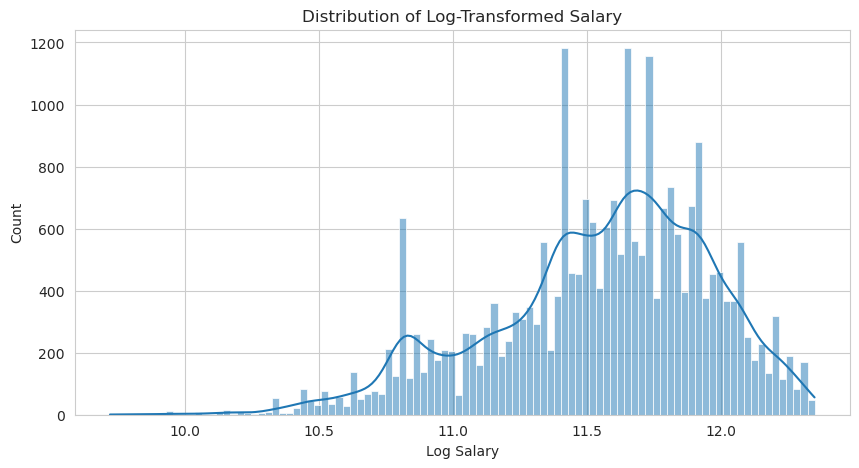

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(jobs_model["salary_log"], bins=100, kde=True)
plt.title("Distribution of Log-Transformed Salary")
plt.xlabel("Log Salary")
plt.ylabel("Count")
plt.show()

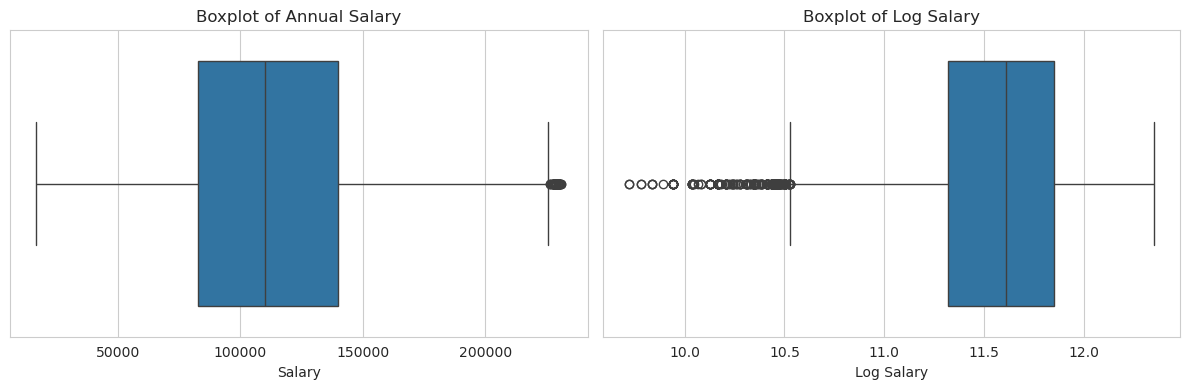

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=jobs_model["salary"], ax=axes[0])
axes[0].set_title("Boxplot of Annual Salary")
axes[0].set_xlabel("Salary")

sns.boxplot(x=jobs_model["salary_log"], ax=axes[1])
axes[1].set_title("Boxplot of Log Salary")
axes[1].set_xlabel("Log Salary")

plt.tight_layout()
plt.show()

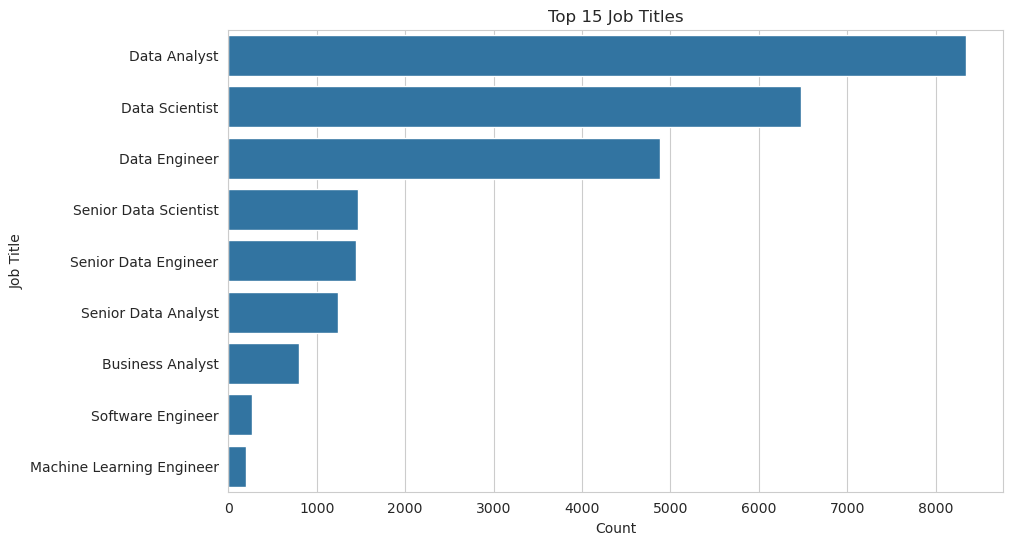

In [20]:
top_titles = jobs_model["job_title_short"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_titles.values, y=top_titles.index)
plt.title("Top 15 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

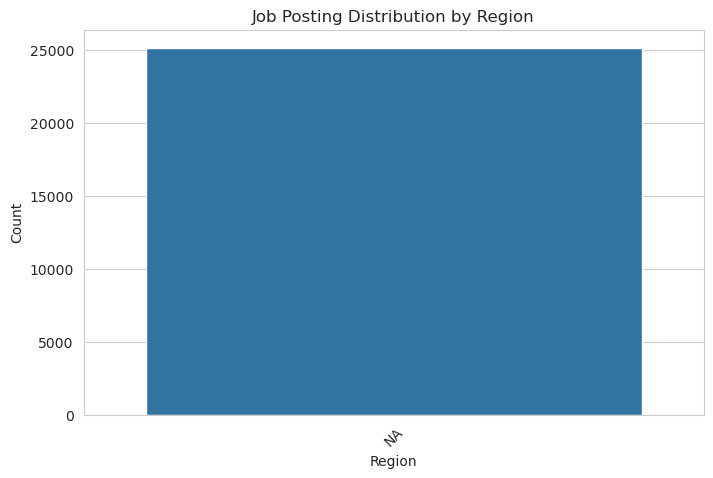

In [21]:
top_regions = jobs_model["region"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_regions.index, y=top_regions.values)
plt.title("Job Posting Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

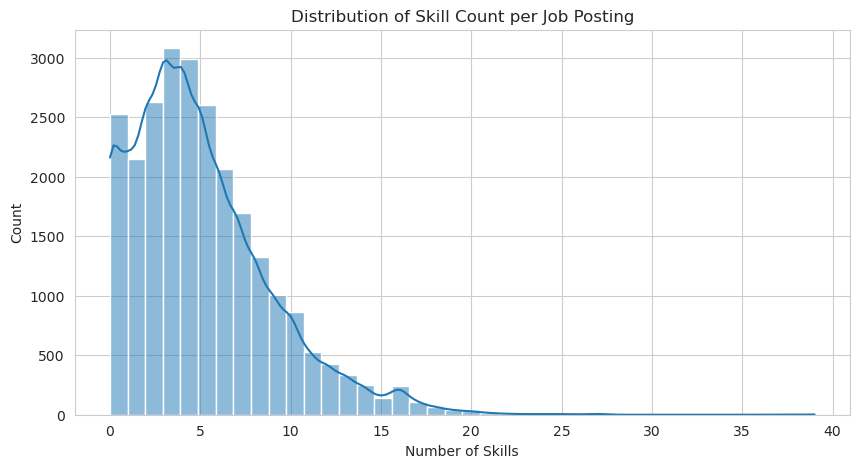

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(jobs_model["skill_count"], bins=40, kde=True)
plt.title("Distribution of Skill Count per Job Posting")
plt.xlabel("Number of Skills")
plt.ylabel("Count")
plt.show()

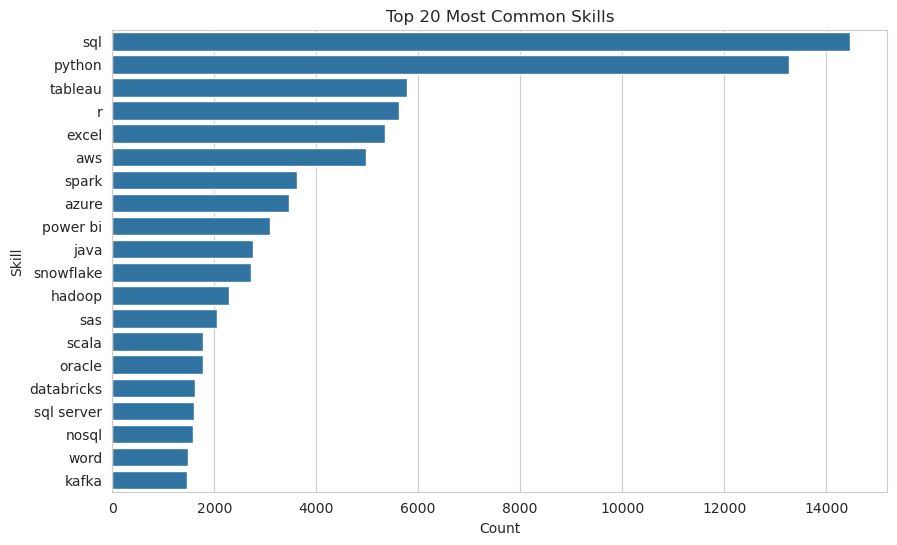

,Skill,Count
0,sql,14475
1,python,13271
2,tableau,5787
3,r,5626
4,excel,5349
5,aws,4968
6,spark,3613
7,azure,3458
8,power bi,3088
9,java,2764


In [23]:
all_skills = [skill for skill_list in jobs_model["skills_list"] for skill in skill_list]
skill_freq = Counter(all_skills)

top_skill_counts = pd.DataFrame(skill_freq.most_common(20), columns=["Skill", "Count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_skill_counts, x="Count", y="Skill")
plt.title("Top 20 Most Common Skills")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

display(top_skill_counts)

In [24]:
skill_category_cols = [f"{cat}_count" for cat in skill_type_categories] + ["num_skill_categories"]

display(jobs_model[skill_category_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
analyst_tools_count,25134.0,1.035768,1.384082,0.0,0.0,0.0,2.0,10.0
cloud_count,25134.0,0.713695,1.134418,0.0,0.0,0.0,1.0,9.0
libraries_count,25134.0,0.651190,1.294267,0.0,0.0,0.0,1.0,15.0
databases_count,25134.0,0.200963,0.580041,0.0,0.0,0.0,0.0,8.0
programming_count,25134.0,2.021525,1.740122,0.0,1.0,2.0,3.0,12.0
other_count,25134.0,0.265139,0.687032,0.0,0.0,0.0,0.0,7.0
webframeworks_count,25134.0,0.047784,0.251966,0.0,0.0,0.0,0.0,5.0
os_count,25134.0,0.057134,0.276678,0.0,0.0,0.0,0.0,4.0
async_count,25134.0,0.050649,0.269877,0.0,0.0,0.0,0.0,4.0
sync_count,25134.0,0.012215,0.119890,0.0,0.0,0.0,0.0,3.0


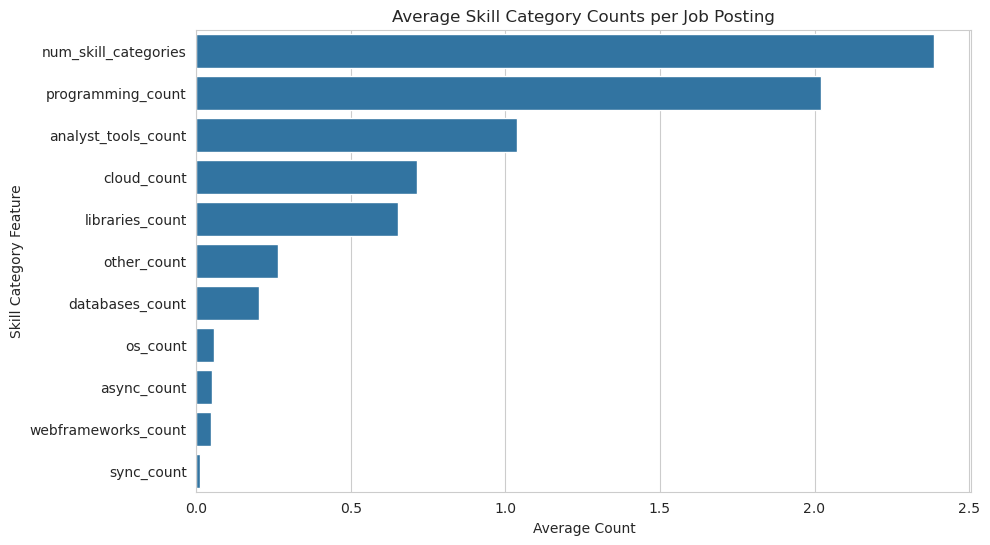

In [25]:
mean_counts = jobs_model[skill_category_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_counts.values, y=mean_counts.index)
plt.title("Average Skill Category Counts per Job Posting")
plt.xlabel("Average Count")
plt.ylabel("Skill Category Feature")
plt.show()

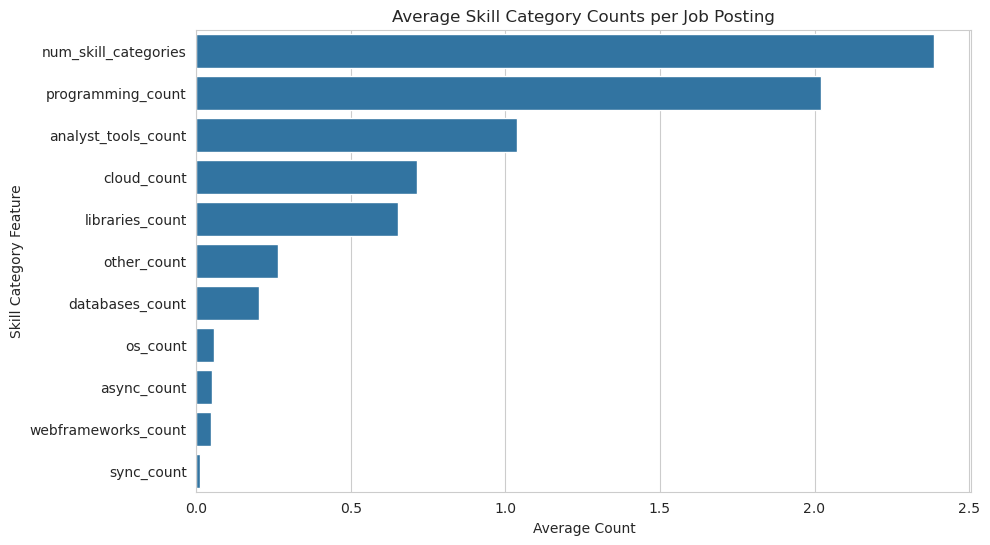

In [26]:
mean_counts = jobs_model[skill_category_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_counts.values, y=mean_counts.index)
plt.title("Average Skill Category Counts per Job Posting")
plt.xlabel("Average Count")
plt.ylabel("Skill Category Feature")
plt.show()

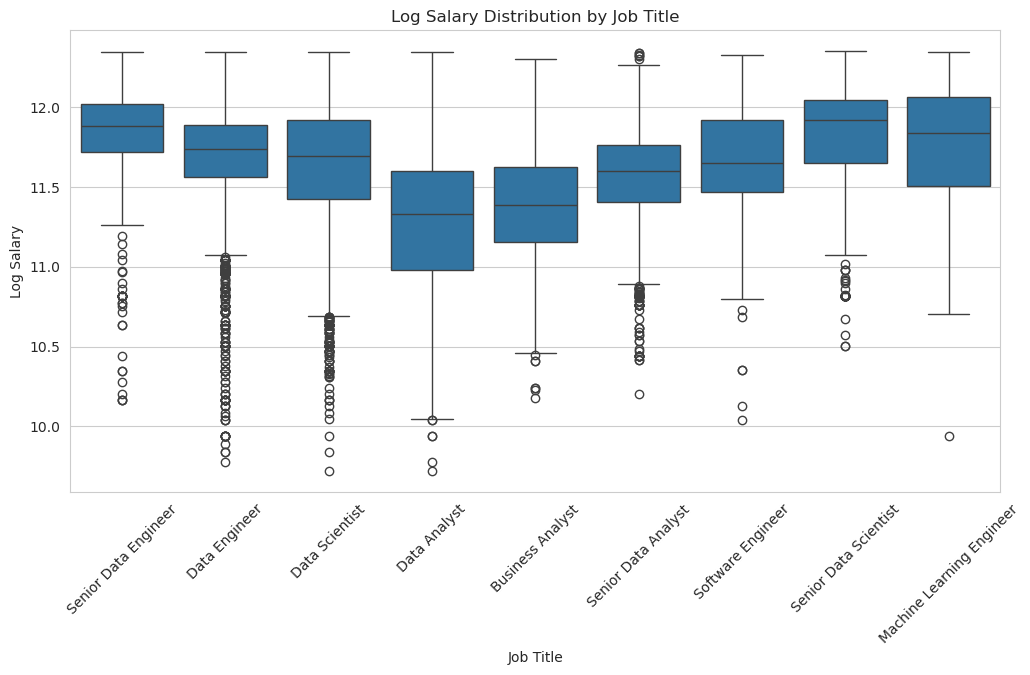

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=jobs_model, x="job_title_short", y="salary_log")
plt.title("Log Salary Distribution by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Log Salary")
plt.xticks(rotation=45)
plt.show()

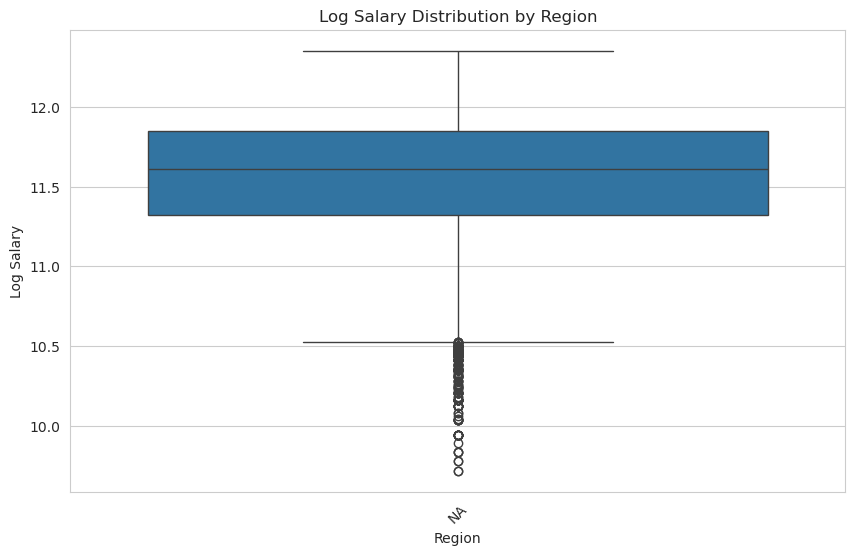

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=jobs_model, x="region", y="salary_log")
plt.title("Log Salary Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Log Salary")
plt.xticks(rotation=45)
plt.show()

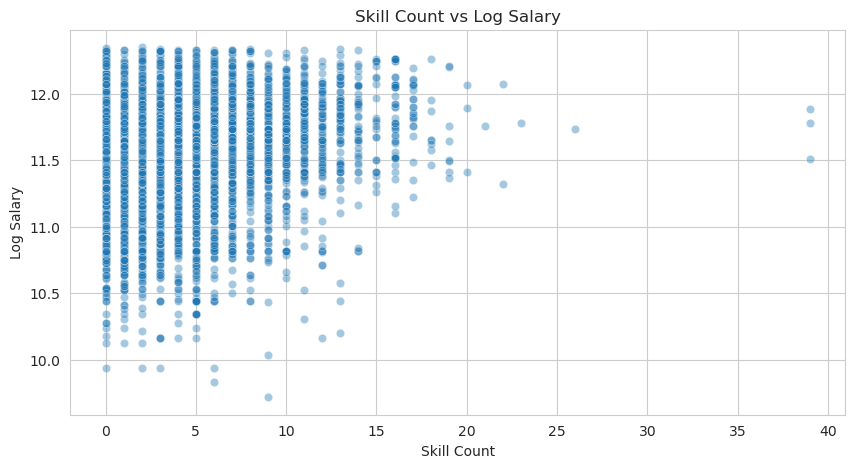

In [29]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=jobs_model.sample(min(5000, len(jobs_model)), random_state=42),
                x="skill_count", y="salary_log", alpha=0.4)
plt.title("Skill Count vs Log Salary")
plt.xlabel("Skill Count")
plt.ylabel("Log Salary")
plt.show()

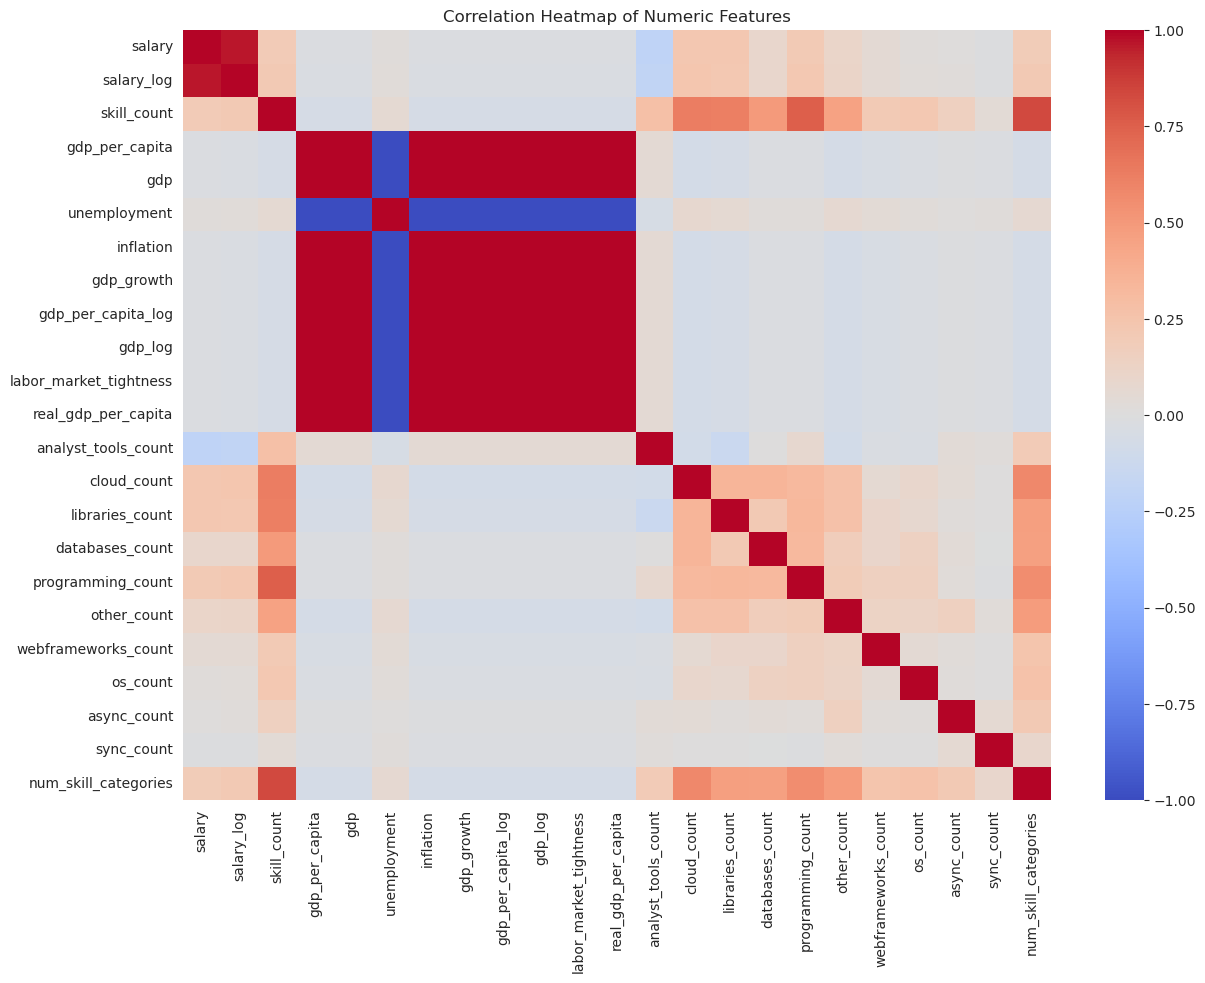

In [30]:
numeric_cols_for_corr = [
    "salary",
    "salary_log",
    "skill_count",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita",
    "analyst_tools_count",
    "cloud_count",
    "libraries_count",
    "databases_count",
    "programming_count",
    "other_count",
    "webframeworks_count",
    "os_count",
    "async_count",
    "sync_count",
    "num_skill_categories"
]

numeric_cols_for_corr = [c for c in numeric_cols_for_corr if c in jobs_model.columns]

corr_matrix = jobs_model[numeric_cols_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

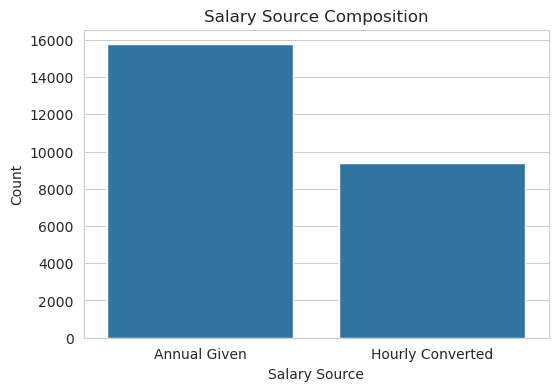

Annual Given        15755
Hourly Converted     9379
Name: count, dtype: int64

In [31]:
salary_source = pd.Series(np.where(jobs_model["salary_year_avg"].notna(), "Annual Given", "Hourly Converted"))
salary_source_counts = salary_source.value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=salary_source_counts.index, y=salary_source_counts.values)
plt.title("Salary Source Composition")
plt.xlabel("Salary Source")
plt.ylabel("Count")
plt.show()

display(salary_source_counts)

# Additional Feature Engineering After EDA

Based on the EDA findings, several additional features are created to better capture salary structure:

- grouped country feature to reduce strong regional imbalance
- title seniority indicators
- title complexity features
- grouped technical stacks such as cloud, visualization, and machine learning tools

These features are added before data splitting so that they can be carried consistently through all modeling methods.

In [32]:
# -------------------------
# ADD COUNTRY GROUPING
# -------------------------
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# -------------------------
# TITLE FEATURES
# -------------------------
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# -------------------------
# STACK FEATURES FROM skills_list
# -------------------------
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit-learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["sql", "python", "r", "excel"])
)

# -------------------------
# FEATURE INTERACTIONS
# -------------------------

jobs_model["senior_x_ml"] = jobs_model["is_senior"] * jobs_model["ml_stack"]
jobs_model["cloud_x_gdp"] = jobs_model["cloud_stack"] * jobs_model["gdp_per_capita_log"]
jobs_model["data_stack_total"] = (
    jobs_model["cloud_stack"] +
    jobs_model["ml_stack"] +
    jobs_model["big_data_stack"]
)

print("Shape after additional feature engineering:", jobs_model.shape)
display(jobs_model.head())

Shape after additional feature engineering: (25134, 60)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,title_length,title_word_count,cloud_stack,visualization_stack,ml_stack,big_data_stack,core_data_stack,senior_x_ml,cloud_x_gdp,data_stack_total
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,60,10,0,0,0,0,1,0,0.000000,0
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,20,3,2,0,0,1,1,0,22.647652,3
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,39,8,0,0,0,0,2,0,0.000000,0
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,39,7,0,0,0,0,3,0,0.000000,0
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,37,5,0,1,0,0,2,0,0.000000,0


# Train / Validation / Test Split

The dataset is split into:
- 70% training
- 15% validation
- 15% test

This allows model training, tuning, and final evaluation on separate data partitions.

In [33]:
train_idx, temp_idx = train_test_split(
    jobs_model.index,
    test_size=0.30,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

train_df = jobs_model.loc[train_idx].copy()
val_df = jobs_model.loc[val_idx].copy()
test_df = jobs_model.loc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (17593, 60)
Validation shape: (3770, 60)
Test shape: (3771, 60)


In [34]:
# -------------------------
# TARGET ENCODING (FIXED)
# -------------------------

def target_encode(train, val, test, col, target):
    means = train.groupby(col)[target].mean()
    global_mean = train[target].mean()

    train = train.copy()
    val = val.copy()
    test = test.copy()

    train[f"{col}_te"] = train[col].map(means).fillna(global_mean)
    val[f"{col}_te"] = val[col].map(means).fillna(global_mean)
    test[f"{col}_te"] = test[col].map(means).fillna(global_mean)

    return train, val, test


for col in ["job_title_short", "country_grouped"]:
    train_df, val_df, test_df = target_encode(
        train_df, val_df, test_df, col, "salary_log"
    )

# Shared Tabular Features

These features are used across all modeling methods and include:
- numeric contextual variables
- engineered skill-category counts
- title features
- binary job attributes
- one-hot encoded categorical variables

In [35]:
common_numeric = [
    "skill_count",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita",
    "unemployment",
    "inflation",
    "gdp_growth",
    "analyst_tools_count",
    "cloud_count",
    "libraries_count",
    "databases_count",
    "programming_count",
    "other_count",
    "webframeworks_count",
    "os_count",
    "async_count",
    "sync_count",
    "num_skill_categories",
    "cloud_stack",
    "visualization_stack",
    "ml_stack",
    "senior_x_ml",
    "cloud_x_gdp",
    "data_stack_total",
    "big_data_stack",
    "core_data_stack",
    "title_length",
    "title_word_count",
    "is_senior",
    "is_lead",
    "is_principal",
    "is_manager",
    "is_junior",
    "is_intern",
    "job_title_short_te",
    "country_grouped_te"
]
common_numeric = [c for c in common_numeric if c in jobs_model.columns]

common_categorical = ["region", "job_schedule_type"]
common_categorical = [c for c in common_categorical if c in jobs_model.columns]

common_binary = ["job_work_from_home", "job_no_degree_mention", "job_health_insurance"]
common_binary = [c for c in common_binary if c in jobs_model.columns]

tabular_df = jobs_model[common_numeric + common_categorical + common_binary].copy()

tabular_df = pd.get_dummies(tabular_df, columns=common_categorical, drop_first=False)

for c in common_binary:
    if c in tabular_df.columns:
        tabular_df[c] = tabular_df[c].fillna(False).astype(int)

tabular_train = tabular_df.loc[train_idx].copy()
tabular_val = tabular_df.loc[val_idx].copy()
tabular_test = tabular_df.loc[test_idx].copy()

y_train = train_df["salary_log"].copy()
y_val = val_df["salary_log"].copy()
y_test = test_df["salary_log"].copy()

y_val_real = np.expm1(y_val)
y_test_real = np.expm1(y_test)

print("Tabular train shape:", tabular_train.shape)
print("Tabular validation shape:", tabular_val.shape)
print("Tabular test shape:", tabular_test.shape)

Tabular train shape: (17593, 64)
Tabular validation shape: (3770, 64)
Tabular test shape: (3771, 64)


# Cross-Validation Setup

A 5-fold cross-validation object is defined for later evaluation and hyperparameter tuning.

In [36]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


# Helper Functions

These helper functions standardize regression evaluation and feature construction.

In [37]:
def regression_metrics(y_true_log, pred_log):
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(y_true_log)
    return {
        "R2": r2_score(y_true_log, pred_log),
        "MAE": mean_absolute_error(true_real, pred_real),
        "RMSE": np.sqrt(mean_squared_error(true_real, pred_real))
    }

def evaluate_dense_models(method_name, X_train, X_eval, y_train, y_eval):
    results = []

    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=500,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=400,
            l2_regularization=0.1,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.5,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),
        "CatBoost": CatBoostRegressor(
            iterations=1200,
            learning_rate=0.03,
            depth=6,
            verbose=0,
            random_state=42
        )
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred_log = model.predict(X_eval)
        m = regression_metrics(y_eval, pred_log)
        results.append({
            "Method": method_name,
            "Model": name,
            **m
        })

    return pd.DataFrame(results).sort_values("R2", ascending=False)

def make_top_skill_matrix(train_skills, other_skills, mlb=None, top_n=150):
    if mlb is None:
        mlb = MultiLabelBinarizer()
        train_matrix = mlb.fit_transform(train_skills)
    else:
        train_matrix = mlb.transform(train_skills)

    train_df_sk = pd.DataFrame(train_matrix, columns=mlb.classes_, index=train_skills.index)

    top_skills = train_df_sk.sum().sort_values(ascending=False).head(top_n).index.tolist()
    train_df_sk = train_df_sk[top_skills]

    other_matrix = mlb.transform(other_skills)
    other_df_sk = pd.DataFrame(other_matrix, columns=mlb.classes_, index=other_skills.index)

    for c in top_skills:
        if c not in other_df_sk.columns:
            other_df_sk[c] = 0

    other_df_sk = other_df_sk[top_skills]

    return train_df_sk, other_df_sk, top_skills, mlb

def xgb_safe_df(df):
    df = df.copy()

    # 1. flatten nested objects
    for col in df.columns:
        if df[col].apply(lambda x: isinstance(x, (pd.DataFrame, list, dict, tuple))).any():
            df[col] = df[col].astype(str)

    # 2. force numeric
    df = df.apply(pd.to_numeric, errors="coerce")

    # 3. remove duplicate columns (VERY IMPORTANT)
    df = df.loc[:, ~df.columns.duplicated()]

    # 4. final cleanup
    df = df.fillna(0)

    return df.astype("float32")

def lgbm_safe_columns(df):
    df = df.copy()

    def clean(name):
        name = str(name)
        name = name.lower()
        name = re.sub(r"[^\w]", "_", name)   # replace EVERYTHING non-alphanumeric
        name = re.sub(r"_+", "_", name)      # collapse multiple _
        return name.strip("_")

    df.columns = [clean(c) for c in df.columns]

    # remove duplicates AFTER cleaning
    df = df.loc[:, ~df.columns.duplicated()]

    return df

def safe_name(s):
    s = str(s)
    s = re.sub(r"[^\w]", "_", s)   # replace everything unsafe
    s = re.sub(r"_+", "_", s)      # collapse underscores
    return s.strip("_")

# Method A: Baseline Multi-Hot Skill Features

This baseline method uses:
- shared tabular features
- top 150 multi-hot encoded skills
- grouped skill-family counts

In [38]:
skill_train_A, skill_val_A, top_skills_A, mlb_A = make_top_skill_matrix(
    train_df["skills_list"],
    val_df["skills_list"],
    top_n=150
)

_, skill_test_A, _, _ = make_top_skill_matrix(
    train_df["skills_list"],
    test_df["skills_list"],
    mlb=mlb_A,
    top_n=150
)

print(skill_train_A.shape, skill_val_A.shape, skill_test_A.shape)

for df_sk in [skill_train_A, skill_val_A, skill_test_A]:
    for col in ["aws", "azure", "gcp", "tableau", "power_bi", "looker", "qlik",
                "tensorflow", "pytorch", "scikit_learn", "keras"]:
        if col not in df_sk.columns:
            df_sk[col] = 0

skill_train_A["cloud_skills"] = skill_train_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_val_A["cloud_skills"] = skill_val_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_test_A["cloud_skills"] = skill_test_A[["aws", "azure", "gcp"]].sum(axis=1)

skill_train_A["bi_tools"] = skill_train_A[["tableau", "power_bi", "looker", "qlik"]].sum(axis=1)
skill_val_A["bi_tools"] = skill_val_A[["tableau", "power_bi", "looker", "qlik"]].sum(axis=1)
skill_test_A["bi_tools"] = skill_test_A[["tableau", "power_bi", "looker", "qlik"]].sum(axis=1)

skill_train_A["ml_tools"] = skill_train_A[["tensorflow", "pytorch", "scikit_learn", "keras"]].sum(axis=1)
skill_val_A["ml_tools"] = skill_val_A[["tensorflow", "pytorch", "scikit_learn", "keras"]].sum(axis=1)
skill_test_A["ml_tools"] = skill_test_A[["tensorflow", "pytorch", "scikit_learn", "keras"]].sum(axis=1)

X_train_A = pd.concat(
    [tabular_train.reset_index(drop=True),
     skill_train_A.reset_index(drop=True)],
    axis=1
)

X_val_A = pd.concat(
    [tabular_val.reset_index(drop=True),
     skill_val_A.reset_index(drop=True)],
    axis=1
)

X_test_A = pd.concat(
    [tabular_test.reset_index(drop=True),
     skill_test_A.reset_index(drop=True)],
    axis=1
)

assert X_train_A.shape[1] == X_val_A.shape[1]
assert X_train_A.shape[1] == X_test_A.shape[1]

(17593, 150) (3770, 150) (3771, 150)


/opt/conda/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['clickup', 'delphi', 'lisp', 'svelte'] will be ignored
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['clickup', 'svelte'] will be ignored
  warnings.warn(


In [39]:
X_train_A = xgb_safe_df(X_train_A)
X_val_A = xgb_safe_df(X_val_A)
X_test_A = xgb_safe_df(X_test_A)

for col in X_train_A.columns:
    assert not isinstance(X_train_A[col].iloc[0], pd.DataFrame), col

In [40]:
X_train_A = lgbm_safe_columns(X_train_A)
X_val_A = lgbm_safe_columns(X_val_A)
X_test_A = lgbm_safe_columns(X_test_A)

X_val_A = X_val_A.reindex(columns=X_train_A.columns, fill_value=0)
X_test_A = X_test_A.reindex(columns=X_train_A.columns, fill_value=0)

In [41]:
X_train_A = xgb_safe_df(X_train_A)
X_val_A = xgb_safe_df(X_val_A)
X_test_A = xgb_safe_df(X_test_A)

baseline_val_results_df = evaluate_dense_models(
    method_name="Baseline Multi-Hot",
    X_train=X_train_A,
    X_eval=X_val_A,
    y_train=y_train,
    y_eval=y_val
)

display(baseline_val_results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 605
[LightGBM] [Info] Number of data points in the train set: 17593, number of used features: 196
[LightGBM] [Info] Start training from score 11.549720


,Method,Model,R2,MAE,RMSE
2,Baseline Multi-Hot,XGBoost,0.374032,25911.567895,34100.548018
3,Baseline Multi-Hot,LightGBM,0.364169,26081.621064,34342.474138
4,Baseline Multi-Hot,CatBoost,0.353890,26722.171854,34749.315096
1,Baseline Multi-Hot,HistGradientBoosting,0.348436,26671.332789,34794.726030
0,Baseline Multi-Hot,Random Forest,0.325092,27478.422701,35563.267166


# Cross-Validation on the Baseline Method

The strongest baseline model is evaluated using 5-fold cross-validation on the training data.

In [42]:
baseline_best_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

baseline_cv_scores = cross_val_score(
    baseline_best_model,
    X_train_A,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Baseline XGBoost CV R2 scores:", baseline_cv_scores)
print("Baseline XGBoost mean CV R2:", baseline_cv_scores.mean())

Baseline XGBoost CV R2 scores: [0.38368266 0.36911303 0.35884712 0.41078038 0.35772415]
Baseline XGBoost mean CV R2: 0.3760294676477941


# Method B: Frequent Skill Pair Features

This method adds top co-occurring skill-pair indicators to the baseline feature set.

In [43]:
top_skill_set_B = set(top_skills_A)

train_filtered_skills_B = train_df["skills_list"].apply(
    lambda skills: [s for s in skills if s in top_skill_set_B]
)
val_filtered_skills_B = val_df["skills_list"].apply(
    lambda skills: [s for s in skills if s in top_skill_set_B]
)
test_filtered_skills_B = test_df["skills_list"].apply(
    lambda skills: [s for s in skills if s in top_skill_set_B]
)

pair_counter = Counter()
for skills in train_filtered_skills_B:
    unique_skills = sorted(set(skills))
    pair_counter.update(combinations(unique_skills, 2))

top_pairs = pair_counter.most_common(30)

pair_train_B = pd.DataFrame(index=train_df.index)
pair_val_B = pd.DataFrame(index=val_df.index)
pair_test_B = pd.DataFrame(index=test_df.index)

for pair, _ in top_pairs:
    col_name = f"{safe_name(pair[0])}__{safe_name(pair[1])}"
    pair_train_B[col_name] = train_filtered_skills_B.apply(lambda skills: int(pair[0] in skills and pair[1] in skills))
    pair_val_B[col_name] = val_filtered_skills_B.apply(lambda skills: int(pair[0] in skills and pair[1] in skills))
    pair_test_B[col_name] = test_filtered_skills_B.apply(lambda skills: int(pair[0] in skills and pair[1] in skills))

X_train_B = pd.concat([tabular_train, skill_train_A, pair_train_B], axis=1)
X_val_B = pd.concat([tabular_val, skill_val_A, pair_val_B], axis=1)
X_test_B = pd.concat([tabular_test, skill_test_A, pair_test_B], axis=1)

X_train_B = lgbm_safe_columns(X_train_B)
X_val_B = lgbm_safe_columns(X_val_B)
X_test_B = lgbm_safe_columns(X_test_B)

X_val_B = X_val_B.reindex(columns=X_train_B.columns, fill_value=0)
X_test_B = X_test_B.reindex(columns=X_train_B.columns, fill_value=0)

pair_val_results_df = evaluate_dense_models(
    method_name="Skill Pair Features",
    X_train=X_train_B,
    X_eval=X_val_B,
    y_train=y_train,
    y_eval=y_val
)

display(pair_val_results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 17593, number of used features: 226
[LightGBM] [Info] Start training from score 11.549720


,Method,Model,R2,MAE,RMSE
2,Skill Pair Features,XGBoost,0.369507,25971.689079,34194.171582
3,Skill Pair Features,LightGBM,0.362106,26106.336977,34401.588294
4,Skill Pair Features,CatBoost,0.355698,26709.260885,34710.196846
1,Skill Pair Features,HistGradientBoosting,0.343076,26793.789808,34920.062658
0,Skill Pair Features,Random Forest,0.321165,27521.651626,35655.035351


# Method C: NMF Skill Bundles

In [44]:
nmf = NMF(
    n_components=10,
    init="nndsvda",
    max_iter=500,
    random_state=42
)

bundle_train_C = nmf.fit_transform(skill_train_A)
bundle_val_C = nmf.transform(skill_val_A)
bundle_test_C = nmf.transform(skill_test_A)

bundle_train_C = pd.DataFrame(bundle_train_C, columns=[f"bundle_{i}" for i in range(bundle_train_C.shape[1])], index=train_df.index)
bundle_val_C = pd.DataFrame(bundle_val_C, columns=[f"bundle_{i}" for i in range(bundle_val_C.shape[1])], index=val_df.index)
bundle_test_C = pd.DataFrame(bundle_test_C, columns=[f"bundle_{i}" for i in range(bundle_test_C.shape[1])], index=test_df.index)

bundle_train_C = lgbm_safe_columns(bundle_train_C)
bundle_val_C = lgbm_safe_columns(bundle_val_C)
bundle_test_C = lgbm_safe_columns(bundle_test_C)

for i, comp in enumerate(nmf.components_):
    top_idx = np.argsort(comp)[::-1][:10]
    top_terms = skill_train_A.columns[top_idx].tolist()
    print(f"Bundle {i}: {top_terms}")

X_train_C = pd.concat([tabular_train, bundle_train_C], axis=1)
X_val_C = pd.concat([tabular_val, bundle_val_C], axis=1)
X_test_C = pd.concat([tabular_test, bundle_test_C], axis=1)

X_train_C = lgbm_safe_columns(X_train_C)
X_val_C = lgbm_safe_columns(X_val_C)
X_test_C = lgbm_safe_columns(X_test_C)

def assert_lgbm_safe(df):
    bad = [c for c in df.columns if not str(c).replace("_", "").isalnum()]
    print("Bad columns:", bad[:10])
    assert len(bad) == 0

assert_lgbm_safe(X_train_C)

Bundle 0: ['cloud_skills', 'aws', 'redshift', 'snowflake', 'gcp', 'airflow', 'git', 'terraform', 'docker', 'postgresql']
Bundle 1: ['bi_tools', 'tableau', 'looker', 'qlik', 'alteryx', 'snowflake', 'microstrategy', 'bigquery', 'matplotlib', 'cognos']
Bundle 2: ['r', 'sas', 'spss', 'matlab', 'python', 'hadoop', 'sql', 'tableau', 'spark', 'ggplot2']
Bundle 3: ['ml_tools', 'tensorflow', 'pytorch', 'keras', 'scikit-learn', 'pandas', 'numpy', 'spark', 'docker', 'git']
Bundle 4: ['sql', 'sql server', 'oracle', 'snowflake', 'flow', 'jira', 'go', 'ssis', 'bigquery', 'ssrs']
Bundle 5: ['spark', 'hadoop', 'java', 'scala', 'kafka', 'nosql', 'mysql', 'shell', 'cassandra', 'redshift']
Bundle 6: ['excel', 'powerpoint', 'word', 'outlook', 'sas', 'sap', 'sharepoint', 'vba', 'visio', 'spss']
Bundle 7: ['cloud_skills', 'azure', 'databricks', 'gcp', 'ssis', 'sql server', 'pyspark', 'nosql', 'snowflake', 'c#']
Bundle 8: ['python', 'java', 'pandas', 'javascript', 'pyspark', 'git', 'c++', 'go', 'databricks',

In [45]:
nmf_val_results_df = evaluate_dense_models(
    method_name="NMF Skill Bundles",
    X_train=X_train_C,
    X_eval=X_val_C,
    y_train=y_train,
    y_eval=y_val
)

display(nmf_val_results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2855
[LightGBM] [Info] Number of data points in the train set: 17593, number of used features: 59
[LightGBM] [Info] Start training from score 11.549720


,Method,Model,R2,MAE,RMSE
2,NMF Skill Bundles,XGBoost,0.377871,25641.147075,33967.940132
3,NMF Skill Bundles,LightGBM,0.370969,25987.418181,34187.612983
1,NMF Skill Bundles,HistGradientBoosting,0.357243,26401.095712,34578.559525
4,NMF Skill Bundles,CatBoost,0.357198,26646.062898,34667.574543
0,NMF Skill Bundles,Random Forest,0.350095,26611.641968,34804.666678


# Method D: Skill Clustering

In [46]:
co_matrix = skill_train_A.T.dot(skill_train_A)
np.fill_diagonal(co_matrix.values, 0)

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(co_matrix)

skill_cluster_df = pd.DataFrame({
    "skill": co_matrix.index,
    "cluster": cluster_labels
})

for c in range(n_clusters):
    cluster_skills = skill_cluster_df[skill_cluster_df["cluster"] == c]["skill"].tolist()
    print(f"Cluster {c}: {cluster_skills[:15]}")

cluster_train_D = pd.DataFrame(index=train_df.index)
cluster_val_D = pd.DataFrame(index=val_df.index)
cluster_test_D = pd.DataFrame(index=test_df.index)

for c in range(n_clusters):
    cluster_skills = skill_cluster_df[skill_cluster_df["cluster"] == c]["skill"].tolist()
    valid_skills = [s for s in cluster_skills if s in skill_train_A.columns]

    cluster_train_D[f"cluster_{c}"] = skill_train_A[valid_skills].sum(axis=1)
    cluster_val_D[f"cluster_{c}"] = skill_val_A[valid_skills].sum(axis=1)
    cluster_test_D[f"cluster_{c}"] = skill_test_A[valid_skills].sum(axis=1)

X_train_D = pd.concat([tabular_train, cluster_train_D], axis=1)
X_val_D = pd.concat([tabular_val, cluster_val_D], axis=1)
X_test_D = pd.concat([tabular_test, cluster_test_D], axis=1)

X_train_D = lgbm_safe_columns(X_train_D)
X_val_D   = lgbm_safe_columns(X_val_D)
X_test_D  = lgbm_safe_columns(X_test_D)

def debug_bad_columns(df):
    bad = [c for c in df.columns if not str(c).replace("_", "").isalnum()]
    print(f"{len(bad)} bad columns")
    print(bad[:10])

debug_bad_columns(X_train_D)

Cluster 0: ['go', 'word', 'powerpoint', 'flow', 'tensorflow', 'pandas', 'pyspark', 'pytorch', 'docker', 'javascript', 'shell', 'jira', 'c++', 'looker', 'sap']
Cluster 1: ['aws', 'spark', 'azure']
Cluster 2: ['python']
Cluster 3: ['sql']
Cluster 4: ['excel', 'power bi', 'java', 'snowflake', 'hadoop', 'sas', 'oracle', 'scala', 'databricks', 'sql server', 'nosql', 'redshift', 'kafka', 'git', 'airflow']
Cluster 5: ['bi_tools']
Cluster 6: ['cloud_skills']
Cluster 7: ['tableau', 'r']
0 bad columns
[]


In [47]:
cluster_val_results_df = evaluate_dense_models(
    method_name="Skill Clustering",
    X_train=X_train_D,
    X_eval=X_val_D,
    y_train=y_train,
    y_eval=y_val
)

display(cluster_val_results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 353
[LightGBM] [Info] Number of data points in the train set: 17593, number of used features: 57
[LightGBM] [Info] Start training from score 11.549720


,Method,Model,R2,MAE,RMSE
2,Skill Clustering,XGBoost,0.358514,26156.011865,34475.086521
4,Skill Clustering,CatBoost,0.348526,26805.233954,34860.935211
3,Skill Clustering,LightGBM,0.347604,26464.948449,34730.850665
0,Skill Clustering,Random Forest,0.337778,27014.862441,35149.172170
1,Skill Clustering,HistGradientBoosting,0.335582,26949.969486,35046.678360


# Method E: Truncated SVD Skill Compression

In [48]:
svd = TruncatedSVD(n_components=20, random_state=42)

svd_train_E = svd.fit_transform(skill_train_A)
svd_val_E = svd.transform(skill_val_A)
svd_test_E = svd.transform(skill_test_A)

print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())

svd_train_E = pd.DataFrame(svd_train_E, columns=[f"svd_skill_{i}" for i in range(svd_train_E.shape[1])], index=train_df.index)
svd_val_E = pd.DataFrame(svd_val_E, columns=[f"svd_skill_{i}" for i in range(svd_val_E.shape[1])], index=val_df.index)
svd_test_E = pd.DataFrame(svd_test_E, columns=[f"svd_skill_{i}" for i in range(svd_test_E.shape[1])], index=test_df.index)

X_train_E = pd.concat([tabular_train, svd_train_E], axis=1)
X_val_E = pd.concat([tabular_val, svd_val_E], axis=1)
X_test_E = pd.concat([tabular_test, svd_test_E], axis=1)

X_train_E = lgbm_safe_columns(X_train_E)
X_val_E   = lgbm_safe_columns(X_val_E)
X_test_E  = lgbm_safe_columns(X_test_E)

svd_val_results_df = evaluate_dense_models(
    method_name="Truncated SVD",
    X_train=X_train_E,
    X_eval=X_val_E,
    y_train=y_train,
    y_eval=y_val
)

display(svd_val_results_df)

Explained variance ratio sum: 0.7061929011318657
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5405
[LightGBM] [Info] Number of data points in the train set: 17593, number of used features: 69
[LightGBM] [Info] Start training from score 11.549720


,Method,Model,R2,MAE,RMSE
2,Truncated SVD,XGBoost,0.381337,25610.074261,33775.306989
3,Truncated SVD,LightGBM,0.374092,25829.612176,34000.190790
4,Truncated SVD,CatBoost,0.357524,26581.421346,34585.947216
1,Truncated SVD,HistGradientBoosting,0.353427,26449.824615,34569.661491
0,Truncated SVD,Random Forest,0.347450,26603.644628,34869.288757


# Method F: Enhanced Hybrid with Text Features

In [49]:
pip install sentence_transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [50]:
# ===================
# SENTENCE EMBEDDINGS + TEXT FEATURES
# ===================

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# -------------------
# 1. LOAD SBERT MODEL
# -------------------
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# -------------------
# 2. SEPARATE TEXT INPUTS (FIXED)
# -------------------

# SBERT → job title only
train_title_text = train_df["job_title"].fillna("").astype(str)
val_title_text   = val_df["job_title"].fillna("").astype(str)
test_title_text  = test_df["job_title"].fillna("").astype(str)

# TF-IDF → skills only
def skills_to_text(x):
    if isinstance(x, list):
        return " ".join(x)
    return ""

train_skill_text = train_df["skills_list"].apply(skills_to_text)
val_skill_text   = val_df["skills_list"].apply(skills_to_text)
test_skill_text  = test_df["skills_list"].apply(skills_to_text)

# -------------------
# 3. SBERT EMBEDDINGS
# -------------------
train_emb = sbert.encode(train_title_text.tolist(), show_progress_bar=True)
val_emb   = sbert.encode(val_title_text.tolist(), show_progress_bar=True)
test_emb  = sbert.encode(test_title_text.tolist(), show_progress_bar=True)

train_emb = pd.DataFrame(train_emb, columns=[f"sbert_{i}" for i in range(train_emb.shape[1])], index=train_df.index)
val_emb   = pd.DataFrame(val_emb,   columns=[f"sbert_{i}" for i in range(val_emb.shape[1])], index=val_df.index)
test_emb  = pd.DataFrame(test_emb,  columns=[f"sbert_{i}" for i in range(test_emb.shape[1])], index=test_df.index)

# -------------------
# 4. TF-IDF + SVD FEATURES
# -------------------
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_text_train = tfidf.fit_transform(train_skill_text)
X_text_val   = tfidf.transform(val_skill_text)
X_text_test  = tfidf.transform(test_skill_text)

svd = TruncatedSVD(n_components=100, random_state=42)

text_train = svd.fit_transform(X_text_train)
text_val   = svd.transform(X_text_val)
text_test  = svd.transform(X_text_test)

text_train_F = pd.DataFrame(text_train, columns=[f"text_svd_{i}" for i in range(text_train.shape[1])], index=train_df.index)
text_val_F   = pd.DataFrame(text_val,   columns=[f"text_svd_{i}" for i in range(text_val.shape[1])], index=val_df.index)
text_test_F  = pd.DataFrame(text_test,  columns=[f"text_svd_{i}" for i in range(text_test.shape[1])], index=test_df.index)

# -------------------
# 5. FINAL FEATURE MATRIX
# -------------------
X_train_F = pd.concat([
    tabular_train,
    skill_train_A,
    pair_train_B,
    train_emb,
    text_train_F
], axis=1)

X_val_F = pd.concat([
    tabular_val,
    skill_val_A,
    pair_val_B,
    val_emb,
    text_val_F
], axis=1)

X_test_F = pd.concat([
    tabular_test,
    skill_test_A,
    pair_test_B,
    test_emb,
    text_test_F
], axis=1)

X_train_F = lgbm_safe_columns(X_train_F)
X_val_F   = lgbm_safe_columns(X_val_F)
X_test_F  = lgbm_safe_columns(X_test_F)

# -------------------
# 6. MODEL EVALUATION
# -------------------
hybrid_val_results_df = evaluate_dense_models(
    method_name="SBERT + TFIDF Hybrid (Final)",
    X_train=X_train_F,
    X_eval=X_val_F,
    y_train=y_train,
    y_eval=y_val
)

display(hybrid_val_results_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/550 [00:00<?, ?it/s]

Batches:   0%|          | 0/118 [00:00<?, ?it/s]

Batches:   0%|          | 0/118 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.075143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 124078
[LightGBM] [Info] Number of data points in the train set: 17593, number of used features: 710
[LightGBM] [Info] Start training from score 11.549720


,Method,Model,R2,MAE,RMSE
2,SBERT + TFIDF Hybrid (Final),XGBoost,0.479353,23041.218494,30873.601808
3,SBERT + TFIDF Hybrid (Final),LightGBM,0.473695,23412.129114,31114.277484
1,SBERT + TFIDF Hybrid (Final),HistGradientBoosting,0.455182,23979.458815,31605.566937
4,SBERT + TFIDF Hybrid (Final),CatBoost,0.452043,24335.009304,31821.917375
0,SBERT + TFIDF Hybrid (Final),Random Forest,0.415759,25053.561580,32942.092405


# Compare Validation Results

In [51]:
all_val_results_df = pd.concat([
    baseline_val_results_df,
    pair_val_results_df,
    nmf_val_results_df,
    cluster_val_results_df,
    svd_val_results_df,
    hybrid_val_results_df
], ignore_index=True)

all_val_results_df = all_val_results_df.sort_values(["R2", "MAE"], ascending=[False, True]).reset_index(drop=True)

display(all_val_results_df)

,Method,Model,R2,MAE,RMSE
0,SBERT + TFIDF Hybrid (Final),XGBoost,0.479353,23041.218494,30873.601808
1,SBERT + TFIDF Hybrid (Final),LightGBM,0.473695,23412.129114,31114.277484
2,SBERT + TFIDF Hybrid (Final),HistGradientBoosting,0.455182,23979.458815,31605.566937
3,SBERT + TFIDF Hybrid (Final),CatBoost,0.452043,24335.009304,31821.917375
4,SBERT + TFIDF Hybrid (Final),Random Forest,0.415759,25053.561580,32942.092405
5,Truncated SVD,XGBoost,0.381337,25610.074261,33775.306989
6,NMF Skill Bundles,XGBoost,0.377871,25641.147075,33967.940132
7,Truncated SVD,LightGBM,0.374092,25829.612176,34000.190790
8,Baseline Multi-Hot,XGBoost,0.374032,25911.567895,34100.548018
9,NMF Skill Bundles,LightGBM,0.370969,25987.418181,34187.612983


# Hyperparameter Tuning on Best Hybrid Method

For this approach, the best performing on the validation set is the SBERT + TFIDF Hybrid on LightGBM and XGBoost. Thus, these were chosen to perform hyperparameter tuning on. 

### Tuning SBERT + TFIDF Hybrid Methods on LightGBM & XGBoost

In [52]:
from sklearn.model_selection import RandomizedSearchCV

# =========================
# TUNE XGBOOST (SBERT HYBRID)
# =========================

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_param_grid = {
    "n_estimators": [800, 1000, 1200, 1500],
    "learning_rate": [0.01, 0.02, 0.03],
    "max_depth": [4, 5, 6],
    "min_child_weight": [3, 5, 7],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "reg_alpha": [0.1, 0.5, 1],
    "reg_lambda": [1, 2, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(
    xgb_model,
    xgb_param_grid,
    n_iter=20,
    scoring="r2",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_F, y_train)

print("XGB Best Params:", xgb_search.best_params_)
print("XGB Best CV R2:", xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_
best_xgb.fit(X_train_F, y_train)

xgb_pred = best_xgb.predict(X_val_F)
xgb_metrics = regression_metrics(y_val, xgb_pred)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGB Best Params: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 1500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.6}
XGB Best CV R2: 0.47746088774739776


In [53]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from lightgbm import LGBMRegressor, early_stopping
from scipy.stats import randint, uniform

# =====================================
# FAST LIGHTGBM TUNING (<30 mins target)
# =====================================

cv_lgbm = KFold(n_splits=3, shuffle=True, random_state=42)

# Base model
lgbm_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Faster randomized distributions
lgbm_param_grid = {
    "n_estimators": randint(300, 900),          # smaller trees
    "learning_rate": uniform(0.02, 0.05),      # 0.02 to 0.07
    "num_leaves": randint(20, 80),
    "max_depth": [-1, 5, 7, 9],
    "min_child_samples": randint(10, 50),
    "subsample": uniform(0.7, 0.25),           # 0.70 to 0.95
    "colsample_bytree": uniform(0.7, 0.25),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 3)
}

# Randomized Search
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_grid,
    n_iter=20,                 # reduced from 60
    scoring="r2",
    cv=cv_lgbm,                # reduced from 5 folds
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Run search
lgbm_search.fit(X_train_F, y_train)

print("Best Params:", lgbm_search.best_params_)
print("Best CV R2:", lgbm_search.best_score_)

# =====================================
# Train final best model
# =====================================

best_lgbm = lgbm_search.best_estimator_

best_lgbm.fit(
    X_train_F,
    y_train,
    eval_set=[(X_val_F, y_val)],
    eval_metric="l2",
    callbacks=[early_stopping(50, verbose=False)]   # reduced from 100
)

# Predict
lgbm_pred = best_lgbm.predict(X_val_F)

# Evaluate
lgbm_metrics = regression_metrics(y_val, lgbm_pred)

print("Validation Metrics:")
print(lgbm_metrics)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'colsample_bytree': 0.8356740207895621, 'learning_rate': 0.027046211248738135, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 820, 'num_leaves': 43, 'reg_alpha': 0.3948815181755697, 'reg_lambda': 1.3804645241541142, 'subsample': 0.703519955678771}
Best CV R2: 0.4660896904834346
Validation Metrics:
{'R2': 0.46807557444573367, 'MAE': 23604.190672199675, 'RMSE': 31328.739516560912}


In [54]:
print("LGBM Best Params:", lgbm_search.best_params_)
print("LGBM Best CV R2:", lgbm_search.best_score_)
print("Validation Metrics:", lgbm_metrics)
print("Best iteration:", best_lgbm.best_iteration_)

LGBM Best Params: {'colsample_bytree': 0.8356740207895621, 'learning_rate': 0.027046211248738135, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 820, 'num_leaves': 43, 'reg_alpha': 0.3948815181755697, 'reg_lambda': 1.3804645241541142, 'subsample': 0.703519955678771}
LGBM Best CV R2: 0.4660896904834346
Validation Metrics: {'R2': 0.46807557444573367, 'MAE': 23604.190672199675, 'RMSE': 31328.739516560912}
Best iteration: 820


In [55]:
tuned_results_df = pd.DataFrame([
    {
        "Method": "Tuned SBERT +TFIDF Hybrid",
        "Model": "XGBoost",
        **xgb_metrics
    },
    {
        "Method": "Tuned SBERT + TFIDF Hybrid",
        "Model": "LightGBM",
        **lgbm_metrics
    }
])

display(tuned_results_df)

,Method,Model,R2,MAE,RMSE
0,Tuned SBERT +TFIDF Hybrid,XGBoost,0.476281,23234.300701,31032.387472
1,Tuned SBERT + TFIDF Hybrid,LightGBM,0.468076,23604.190672,31328.739517


# Advanced Machine Learning Experiments

This section builds a stronger hybrid representation using:
- enriched tabular features
- top skill multi-hot features
- skill pair indicators
- text embeddings
- Word2Vec skill embeddings

In [56]:
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
!pip install gensim

try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    GENSIM_AVAILABLE = False
    print("gensim is not installed. Install it first with: pip install gensim")

Defaulting to user installation because normal site-packages is not writeable


In [57]:
if GENSIM_AVAILABLE:
    skill_sentences = train_df["skills_list"].tolist()

    w2v_model = Word2Vec(
        sentences=skill_sentences,
        vector_size=50,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        epochs=30
    )

    def average_skill_embedding(skills, model, vector_size=50):
        valid_vectors = [model.wv[s] for s in skills if s in model.wv]
        if len(valid_vectors) == 0:
            return np.zeros(vector_size)
        return np.mean(valid_vectors, axis=0)

    skill_embed_train = np.vstack(train_df["skills_list"].apply(lambda x: average_skill_embedding(x, w2v_model, 50)).values)
    skill_embed_val = np.vstack(val_df["skills_list"].apply(lambda x: average_skill_embedding(x, w2v_model, 50)).values)
    skill_embed_test = np.vstack(test_df["skills_list"].apply(lambda x: average_skill_embedding(x, w2v_model, 50)).values)

    skill_embed_train = pd.DataFrame(skill_embed_train, columns=[f"skill_embed_{i}" for i in range(skill_embed_train.shape[1])], index=train_df.index)
    skill_embed_val = pd.DataFrame(skill_embed_val, columns=[f"skill_embed_{i}" for i in range(skill_embed_val.shape[1])], index=val_df.index)
    skill_embed_test = pd.DataFrame(skill_embed_test, columns=[f"skill_embed_{i}" for i in range(skill_embed_test.shape[1])], index=test_df.index)

    X_train_super = pd.concat([tabular_train, skill_train_A, pair_train_B, text_train_F, skill_embed_train], axis=1)
    X_val_super = pd.concat([tabular_val, skill_val_A, pair_val_B, text_val_F, skill_embed_val], axis=1)
    X_test_super = pd.concat([tabular_test, skill_test_A, pair_test_B, text_test_F, skill_embed_test], axis=1)

    scaler_super = StandardScaler()
    X_train_super_scaled = scaler_super.fit_transform(X_train_super)
    X_val_super_scaled = scaler_super.transform(X_val_super)

    models_super = {
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.04,
            max_depth=8,
            max_iter=500,
            l2_regularization=0.1,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1500,
            learning_rate=0.02,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.8,
            reg_alpha=0.05,
            reg_lambda=1.5,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=300,
            random_state=42
        )
    }

    super_results = []

    for name, model in models_super.items():
        if name == "MLP":
            model.fit(X_train_super_scaled, y_train)
            pred_log = model.predict(X_val_super_scaled)
        else:
            model.fit(X_train_super, y_train)
            pred_log = model.predict(X_val_super)

        m = regression_metrics(y_val, pred_log)
        super_results.append({
            "Method": "Super Hybrid + Embeddings",
            "Model": name,
            "R2": m["R2"],
            "MAE": m["MAE"],
            "RMSE": m["RMSE"]
        })

    super_results_df = pd.DataFrame(super_results).sort_values(["R2", "MAE"], ascending=[False, True])
    display(super_results_df)

,Method,Model,R2,MAE,RMSE
2,Super Hybrid + Embeddings,XGBoost,0.387707,25344.424239,33562.220921
1,Super Hybrid + Embeddings,HistGradientBoosting,0.376155,25917.745906,33953.141103
0,Super Hybrid + Embeddings,ExtraTrees,0.369870,25547.693648,34070.350249
3,Super Hybrid + Embeddings,MLP,-0.338599,40087.560846,67829.576970


In [58]:
if GENSIM_AVAILABLE:
    all_results_final_df = pd.concat([
        all_val_results_df,
        tuned_results_df,   # ← NEW (XGB + LGBM)
        super_results_df
    ], ignore_index=True)
else:
    all_results_final_df = pd.concat([
        all_val_results_df,
        tuned_results_df
    ], ignore_index=True)

all_results_final_df = all_results_final_df.sort_values(
    ["R2", "MAE"], ascending=[False, True]
).reset_index(drop=True)

display(all_results_final_df)

,Method,Model,R2,MAE,RMSE
0,SBERT + TFIDF Hybrid (Final),XGBoost,0.479353,23041.218494,30873.601808
1,Tuned SBERT +TFIDF Hybrid,XGBoost,0.476281,23234.300701,31032.387472
2,SBERT + TFIDF Hybrid (Final),LightGBM,0.473695,23412.129114,31114.277484
3,Tuned SBERT + TFIDF Hybrid,LightGBM,0.468076,23604.190672,31328.739517
4,SBERT + TFIDF Hybrid (Final),HistGradientBoosting,0.455182,23979.458815,31605.566937
5,SBERT + TFIDF Hybrid (Final),CatBoost,0.452043,24335.009304,31821.917375
6,SBERT + TFIDF Hybrid (Final),Random Forest,0.415759,25053.561580,32942.092405
7,Super Hybrid + Embeddings,XGBoost,0.387707,25344.424239,33562.220921
8,Truncated SVD,XGBoost,0.381337,25610.074261,33775.306989
9,NMF Skill Bundles,XGBoost,0.377871,25641.147075,33967.940132


In [59]:
# ## START OF ERROR ANALYSIS
# results = test_df.copy()
# results["Actual"] = y_test_real
# results["Predicted"] = pred
# results["Error"] = abs(results["Actual"] - results["Predicted"])
# results["Residual"] = results["Actual"] - results["Predicted"]

# results.groupby("job_title_short")["Error"].mean().sort_values(ascending=False)

# results.groupby("job_country")["Error"].mean()

# results.groupby("job_work_from_home")["Error"].mean()

# results.groupby("is_senior")["Error"].mean()

# ## Misclassified High/Low Salaries
# under = results.sort_values("Residual", ascending=False).head(20)
# over = results.sort_values("Residual").head(20)

# ## Clustering Anlysis
# cluster_features = jobs_model[
# [
# "skill_count",
# "cloud_stack",
# "ml_stack",
# "big_data_stack",
# "is_senior",
# "salary"
# ]
# ]

# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=5, random_state=42)
# jobs_model["cluster"] = kmeans.fit_predict(cluster_features)

# jobs_model.groupby("cluster")["salary"].mean()
# jobs_model.groupby("cluster")["job_title_short"].value_counts()

# ## END

# Final Test Evaluation

After selecting the strongest method on the validation set, the final chosen model should be retrained on train + validation data and then evaluated once on the held-out test set.

## LightGBM

In [65]:
# Example: Using (Non-tuned) SBERT + TFIDF Hybrid LightGBM as final model candidate

trainval_df = pd.concat([train_df, val_df], axis=0)
y_trainval = trainval_df["salary_log"]

tabular_trainval = pd.concat([tabular_train, tabular_val], axis=0)
skill_trainval = pd.concat([skill_train_A, skill_val_A], axis=0)
pair_trainval = pd.concat([pair_train_B, pair_val_B], axis=0)
text_trainval = pd.concat([text_train_F, text_val_F], axis=0)

trainval_emb = pd.concat([train_emb, val_emb], axis=0)

X_trainval_F = pd.concat([
    tabular_trainval,
    skill_trainval,
    pair_trainval,
    trainval_emb,  
    text_trainval  
], axis=1)

X_trainval_F = lgbm_safe_columns(X_trainval_F)
X_test_F = lgbm_safe_columns(X_test_F)

final_model = best_lgbm
final_model.fit(X_trainval_F, y_trainval)

final_pred_test = final_model.predict(X_test_F)
final_test_metrics = regression_metrics(y_test, final_pred_test)

final_test_results_df = pd.DataFrame([{
    "Method": "Final Tuned SBERT + TFIDF Hybrid",
    "Model": "LightGBM",
    "R2": final_test_metrics["R2"],
    "MAE": final_test_metrics["MAE"],
    "RMSE": final_test_metrics["RMSE"]
}])

display(final_test_results_df)

,Method,Model,R2,MAE,RMSE
0,Final Tuned SBERT + TFIDF Hybrid,LightGBM,0.497376,22793.955617,30493.036636


how to explain that 22k is a big or small difference given that our datasets has wide salary range

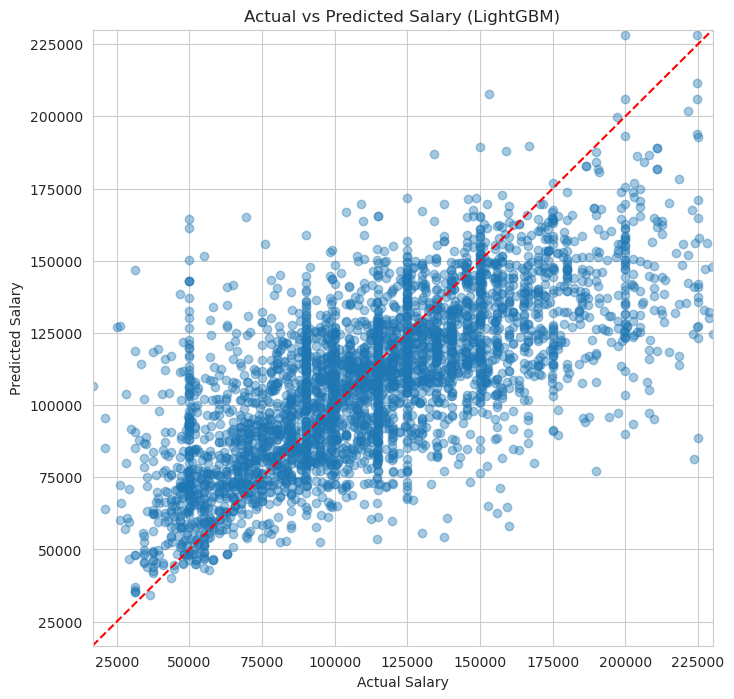

In [66]:
# Fixed Predicted vs Actual Scatterplot

import matplotlib.pyplot as plt
import numpy as np

pred = np.expm1(final_pred_test)
actual = np.expm1(y_test)

plt.figure(figsize=(8,8))
plt.scatter(actual, pred, alpha=0.4)

lims = [
    min(actual.min(), pred.min()),
    max(actual.max(), pred.max())
]

plt.plot(lims, lims, 'r--')
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (LightGBM)")
plt.show()

## XGBoost

In [67]:
# ==========================================
# FINAL MODEL = XGBOOST (SBERT + TFIDF HYBRID)
# Uses Train + Validation -> Final Training
# Evaluates on Test Set
# ==========================================

from xgboost import XGBRegressor
import pandas as pd

# ------------------------------------------
# Combine Train + Validation Sets
# ------------------------------------------

trainval_df = pd.concat([train_df, val_df], axis=0)
y_trainval = trainval_df["salary_log"]

tabular_trainval = pd.concat([tabular_train, tabular_val], axis=0)
skill_trainval   = pd.concat([skill_train_A, skill_val_A], axis=0)
pair_trainval    = pd.concat([pair_train_B, pair_val_B], axis=0)
text_trainval    = pd.concat([text_train_F, text_val_F], axis=0)
trainval_emb     = pd.concat([train_emb, val_emb], axis=0)

# ------------------------------------------
# Build Final Feature Matrix
# ------------------------------------------

X_trainval_F = pd.concat([
    tabular_trainval,
    skill_trainval,
    pair_trainval,
    trainval_emb,
    text_trainval
], axis=1)

X_test_F = pd.concat([
    tabular_test,
    skill_test_A,
    pair_test_B,
    test_emb,
    text_test_F
], axis=1)

# ------------------------------------------
# Clean columns for XGBoost
# ------------------------------------------

X_trainval_F = xgb_safe_df(X_trainval_F)
X_test_F     = xgb_safe_df(X_test_F)

# Ensure same columns
X_test_F = X_test_F.reindex(columns=X_trainval_F.columns, fill_value=0)

# ------------------------------------------
# Use Best Tuned XGBoost Model
# ------------------------------------------

final_model = best_xgb

final_model.fit(X_trainval_F, y_trainval)

# ------------------------------------------
# Predict on Test Set
# ------------------------------------------

final_pred_test = final_model.predict(X_test_F)

# ------------------------------------------
# Evaluate
# ------------------------------------------

final_test__xg_metrics = regression_metrics(y_test, final_pred_test)

final_test_results_xg_df = pd.DataFrame([{
    "Method": "Final Tuned SBERT + TFIDF Hybrid",
    "Model": "XGBoost",
    "R2": final_test_metrics["R2"],
    "MAE": final_test_metrics["MAE"],
    "RMSE": final_test_metrics["RMSE"]
}])

display(final_test_results_xg_df)

,Method,Model,R2,MAE,RMSE
0,Final Tuned SBERT + TFIDF Hybrid,XGBoost,0.497376,22793.955617,30493.036636


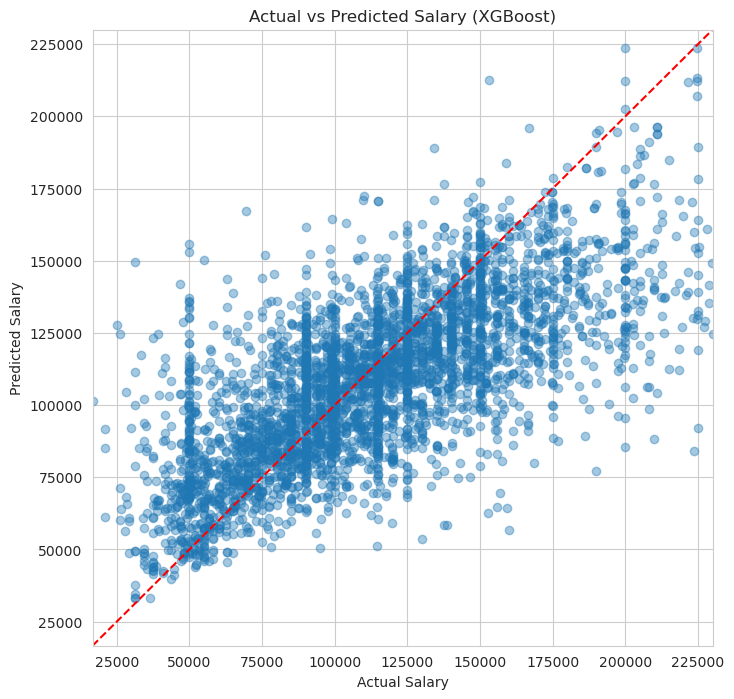

In [68]:
# Fixed Predicted vs Actual Scatterplot

import matplotlib.pyplot as plt
import numpy as np

pred = np.expm1(final_pred_test)
actual = np.expm1(y_test)

plt.figure(figsize=(8,8))
plt.scatter(actual, pred, alpha=0.4)

lims = [
    min(actual.min(), pred.min()),
    max(actual.max(), pred.max())
]

plt.plot(lims, lims, 'r--')
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (XGBoost)")
plt.show()

# Error Analysis

In [69]:
# XGBoost
results = test_df.copy()
results["Actual"] = y_test_real
results["Predicted"] = pred
results["Error"] = abs(results["Actual"] - results["Predicted"])
results["Residual"] = results["Actual"] - results["Predicted"]

In [70]:
## START OF ERROR ANALYSIS
results.groupby("job_title_short")["Error"].mean().sort_values(ascending=False)

job_title_short
Machine Learning Engineer    38464.799307
Senior Data Scientist        28356.974525
Data Scientist               24920.726969
Software Engineer            24345.744485
Senior Data Engineer         23974.983723
Senior Data Analyst          22992.190770
Data Engineer                22450.296678
Business Analyst             20630.659636
Data Analyst                 18871.529039
Name: Error, dtype: float64

In [71]:
results.groupby("job_country")["Error"].mean()

job_country
Canada           24522.345170
United States    22434.328628
Name: Error, dtype: float64

In [72]:
results.groupby("job_work_from_home")["Error"].mean()

job_work_from_home
False    22483.372593
True     22450.266403
Name: Error, dtype: float64

In [73]:
results.groupby("is_senior")["Error"].mean()

is_senior
0    22011.413869
1    24866.029851
Name: Error, dtype: float64

In [74]:
## Misclassified High/Low Salaries
under = results.sort_values("Residual", ascending=False).head(20)
over = results.sort_values("Residual").head(20)

In [75]:
under

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,core_data_stack,senior_x_ml,cloud_x_gdp,data_stack_total,job_title_short_te,country_grouped_te,Actual,Predicted,Error,Residual
125213,Data Engineer,Data Engineer/ Architect - Contract to Hire,Anywhere,via Upwork,Contractor,True,False,False,United States,hour,...,2,0,0.000000,0,11.698110,11.54786,223600.0,83930.414062,139669.585937,139669.585937
185977,Data Analyst,Data Analyst Director,"Boston, MA",via Ladders,Full-time,False,False,True,United States,year,...,3,0,0.000000,0,11.296557,11.54786,225000.0,92071.468750,132928.531250,132928.531250
196060,Data Scientist,Data Scientist/Engineer - Bay Area Startup wit...,"San Jose, CA",via Indeed,Full-time,False,False,False,United States,year,...,0,0,0.000000,0,11.653567,11.54786,210000.0,88311.554688,121688.445312,121688.445312
193280,Data Analyst,Data Analyst（SF）,"San Francisco, CA",via LinkedIn,Full-time,False,False,False,United States,year,...,0,0,0.000000,0,11.296557,11.54786,200000.0,85515.640625,114484.359375,114484.359375
58852,Data Analyst,Marketing Data Analyst,NaN,via LinkedIn,Full-time,False,False,False,United States,year,...,0,0,0.000000,0,11.296557,11.54786,190000.0,77053.398438,112946.601562,112946.601562
75853,Data Engineer,Data Engineer,"McLean, VA",via Adzuna,Full-time,False,False,True,United States,year,...,1,0,22.647652,6,11.698110,11.54786,208114.0,98605.437500,109508.562500,109508.562500
154887,Data Engineer,Lead Data Engineer,"Worcester, MA",via WJHL Jobs,Full-time,False,False,True,United States,year,...,2,0,22.647652,6,11.698110,11.54786,211000.0,104182.226562,106817.773437,106817.773437
41100,Business Analyst,Senior Financial Analyst,"McGregor, TX",via ZipRecruiter,Contractor,False,False,False,United States,hour,...,0,0,0.000000,0,11.385307,11.54786,218400.0,112026.445312,106373.554688,106373.554688
87460,Data Scientist,Data Scientist,"Chicago, IL",via LinkedIn,Full-time,False,False,True,United States,year,...,2,0,0.000000,0,11.653567,11.54786,225000.0,118960.015625,106039.984375,106039.984375
167252,Data Scientist,"Data Scientist, Connect Area","San Francisco, CA",via Ai-Jobs.net,Full-time,False,False,True,United States,year,...,2,0,0.000000,0,11.653567,11.54786,230000.0,124462.601562,105537.398438,105537.398438


In [76]:
over

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,core_data_stack,senior_x_ml,cloud_x_gdp,data_stack_total,job_title_short_te,country_grouped_te,Actual,Predicted,Error,Residual
130988,Senior Data Engineer,Senior Data Engineer,Anywhere,via Upwork,Contractor,True,False,False,United States,hour,...,2,0,11.323826,1,11.829602,11.54786,31200.000000,149416.296875,118216.296875,-118216.296875
68543,Data Scientist,Principal Data Scientist,"Atlanta, GA","via Atlanta, GA - Geebo",Full-time,False,False,False,United States,hour,...,2,0,0.000000,1,11.653567,11.54786,49920.000000,155630.750000,105710.750000,-105710.750000
127328,Senior Data Scientist,"Senior Data Scientist, Analytics - Growth","Austin, TX","via Austin, TX - Geebo",Full-time,False,False,True,United States,hour,...,3,0,0.000000,0,11.820017,11.54786,49920.000000,153183.265625,103263.265625,-103263.265625
69935,Data Analyst,Research Scientist,Anywhere,via ZipRecruiter,Full-time,True,False,True,United States,year,...,0,0,0.000000,0,11.296557,11.54786,25000.000000,127556.546875,102556.546875,-102556.546875
170710,Senior Data Engineer,Senior Data Engineer,Anywhere,via Upwork,Contractor,True,False,False,United States,hour,...,1,0,11.323826,1,11.829602,11.54786,26000.000000,124730.914062,98730.914063,-98730.914063
143476,Data Scientist,"Director, Data Science & Customer Analytics","Columbus, OH",via Snagajob,Full-time,False,False,False,United States,hour,...,2,0,0.000000,0,11.653567,11.54786,69534.400635,167038.843750,97504.443115,-97504.443115
219465,Senior Data Scientist,Senior Lead Fraud Data Scientist Jobs in San F...,"San Francisco, CA",via Usjobscircle.online,Full-time,False,False,False,United States,year,...,3,1,11.323826,3,11.820017,11.54786,55000.000000,150392.140625,95392.140625,-95392.140625
68095,Senior Data Engineer,Senior Data Engineer,Anywhere,via Upwork,Full-time,True,True,False,United States,hour,...,0,0,0.000000,0,11.829602,11.54786,46800.000000,141902.656250,95102.656250,-95102.656250
71904,Senior Data Scientist,Senior Data Scientist- Fraud Detection,"Dania Beach, FL","via Dania, FL - Geebo",Full-time,False,False,False,United States,hour,...,3,0,0.000000,1,11.820017,11.54786,49920.000000,136940.312500,87020.312500,-87020.312500
68058,Senior Data Scientist,Senior Data Scientist - Home,"Charlotte, NC","via Charlotte, NC - Geebo",Full-time,False,False,False,United States,hour,...,2,0,0.000000,1,11.820017,11.54786,49920.000000,135946.812500,86026.812500,-86026.812500


In [77]:
## Clustering Analysis
cluster_features = jobs_model[
[
"skill_count",
"cloud_stack",
"ml_stack",
"big_data_stack",
"is_senior",
"salary"
]
]

In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
jobs_model["cluster"] = kmeans.fit_predict(cluster_features)

In [79]:
jobs_model.groupby("cluster")["salary"].mean()

cluster
0    190194.879897
1     88816.659584
2     54056.598706
3    117860.395216
4    148636.840854
Name: salary, dtype: float64

In [80]:
jobs_model.groupby("cluster")["job_title_short"].value_counts()

cluster  job_title_short          
0        Data Scientist                962
         Data Engineer                 552
         Senior Data Scientist         398
         Senior Data Engineer          347
         Data Analyst                  148
         Senior Data Analyst            82
         Machine Learning Engineer      54
         Software Engineer              43
         Business Analyst               18
1        Data Analyst                 2753
         Data Scientist               1560
         Data Engineer                 882
         Senior Data Analyst           390
         Business Analyst              327
         Senior Data Scientist         197
         Senior Data Engineer          128
         Software Engineer              78
         Machine Learning Engineer      49
2        Data Analyst                 3160
         Data Scientist                724
         Data Engineer                 272
         Business Analyst              207
         Senior Dat

In [81]:
jobs_model.groupby("cluster")[[
"skill_count",
"cloud_stack",
"ml_stack",
"big_data_stack",
"is_senior",
"salary"
]].mean()

,skill_count,cloud_stack,ml_stack,big_data_stack,is_senior,salary
cluster,,,,,,
0,5.914363,0.652074,0.232335,0.676267,0.318356,190194.879897
1,4.671590,0.316625,0.085638,0.219673,0.116750,88816.659584
2,3.433241,0.155309,0.051698,0.098483,0.054903,54056.598706
3,5.358511,0.538906,0.105927,0.373252,0.161246,117860.395216
4,5.703568,0.634047,0.162283,0.524975,0.245464,148636.840854


<Axes: xlabel='cluster'>

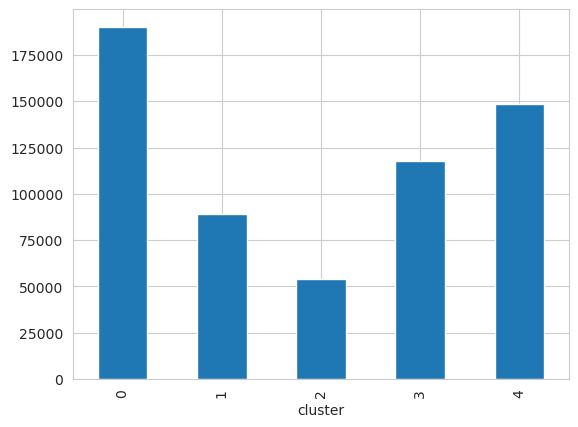

In [82]:
jobs_model.groupby("cluster")["salary"].mean().plot(kind="bar")

<Axes: xlabel='cluster', ylabel='salary'>

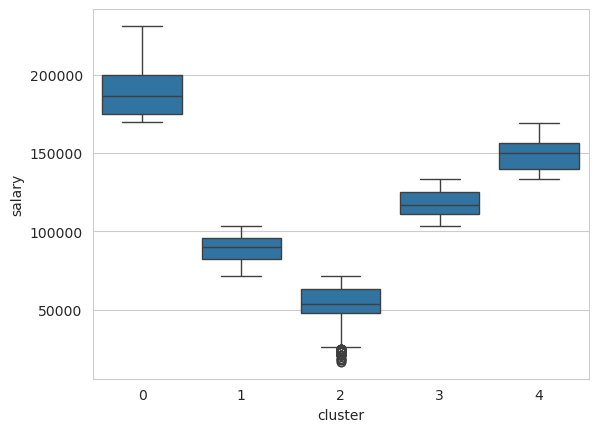

In [83]:
sns.boxplot(data=jobs_model, x="cluster", y="salary")

# END

# Continuation of Orig Code

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# USE LOG VALUES DIRECTLY
y_true = y_test
y_pred = final_pred_test

# sort by actual
sorted_idx = np.argsort(y_true)
y_true_sorted = y_true.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10,5))

plt.plot(y_true_sorted.values, label="Actual (log)", linewidth=2)
plt.plot(y_pred_sorted, label="Predicted (log)", linewidth=2)

plt.xlabel("Samples (sorted by actual log salary)")
plt.ylabel("Log Salary")
plt.title("Actual vs Predicted (Log Scale)")
plt.legend()

plt.show()

In [ ]:
# -------------------------
# EDA-DRIVEN FEATURE ENGINEERING
# -------------------------

# 1. Country grouping (since region alone is too broad)
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# 2. Seniority / level features from title
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

# 3. Title complexity
jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# 4. Skill stacks (based on EDA top skills)
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power_bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit_learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["python", "sql", "r", "excel"])
)

# -------------------------
# FEATURE INTERACTIONS
# -------------------------

jobs_model["senior_x_ml"] = jobs_model["is_senior"] * jobs_model["ml_stack"]
jobs_model["cloud_x_gdp"] = jobs_model["cloud_stack"] * jobs_model["gdp_per_capita_log"]
jobs_model["data_stack_total"] = (
    jobs_model["cloud_stack"] +
    jobs_model["ml_stack"] +
    jobs_model["big_data_stack"]
)

# 5. Nonlinear version of skill count
jobs_model["skill_count_sq"] = jobs_model["skill_count"] ** 2
jobs_model["skill_count_log"] = np.log1p(jobs_model["skill_count"])

print("Shape after EDA-driven feature engineering:", jobs_model.shape)
display(jobs_model.head())

In [ ]:
# -------------------------
# TRAIN / VALIDATION / TEST SPLIT
# -------------------------

train_idx, temp_idx = train_test_split(
    jobs_model.index,
    test_size=0.30,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

train_df = jobs_model.loc[train_idx].copy()
val_df = jobs_model.loc[val_idx].copy()
test_df = jobs_model.loc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

In [ ]:
# -------------------------
# SHARED TABULAR FEATURES
# -------------------------

common_numeric = [
    "skill_count",
    "skill_count_sq",
    "skill_count_log",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita",
    "unemployment",
    "inflation",
    "gdp_growth",
    "analyst_tools_count",
    "cloud_count",
    "libraries_count",
    "databases_count",
    "programming_count",
    "other_count",
    "webframeworks_count",
    "os_count",
    "async_count",
    "sync_count",
    "num_skill_categories",
    "cloud_stack",
    "visualization_stack",
    "ml_stack",
    "senior_x_ml",
    "cloud_x_gdp",
    "data_stack_total",
    "big_data_stack",
    "core_data_stack",
    "title_length",
    "title_word_count",
    "is_senior",
    "is_lead",
    "is_principal",
    "is_manager",
    "is_junior",
    "is_intern",
    "job_title_short_te",
    "country_grouped_te",
    "python_sql",
    "aws_sql",
    "python_spark",
    "tableau_sql",
    "senior_x_core",
    "senior_x_cloud",
    "premium_skill_count"
]
common_numeric = [c for c in common_numeric if c in jobs_model.columns]

common_categorical = [
    "region",
    "job_schedule_type"
]
common_categorical = [c for c in common_categorical if c in jobs_model.columns]

common_binary = [
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance"
]
common_binary = [c for c in common_binary if c in jobs_model.columns]

tabular_df = jobs_model[common_numeric + common_categorical + common_binary].copy()

tabular_df = pd.get_dummies(
    tabular_df,
    columns=common_categorical,
    drop_first=False
)

for c in common_binary:
    if c in tabular_df.columns:
        tabular_df[c] = tabular_df[c].fillna(False).astype(int)

tabular_train = tabular_df.loc[train_idx].copy()
tabular_val = tabular_df.loc[val_idx].copy()
tabular_test = tabular_df.loc[test_idx].copy()

y_train = train_df["salary_log"].copy()
y_val = val_df["salary_log"].copy()
y_test = test_df["salary_log"].copy()

print("Tabular train shape:", tabular_train.shape)
print("Tabular validation shape:", tabular_val.shape)
print("Tabular test shape:", tabular_test.shape)

In [ ]:
# -------------------------
# CROSS-VALIDATION SETUP
# -------------------------
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print(cv)

In [ ]:
# -------------------------
# HELPER FUNCTIONS
# -------------------------

def regression_metrics(y_true_log, pred_log):
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(y_true_log)
    return {
        "R2": r2_score(y_true_log, pred_log),
        "MAE": mean_absolute_error(true_real, pred_real),
        "RMSE": np.sqrt(mean_squared_error(true_real, pred_real))
    }

def evaluate_dense_models(method_name, X_train, X_eval, y_train, y_eval):
    results = []

    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=500,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=400,
            l2_regularization=0.1,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.5,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),
        "CatBoost": CatBoostRegressor(
            iterations=1200,
            learning_rate=0.03,
            depth=6,
            verbose=0,
            random_state=42
        )
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred_log = model.predict(X_eval)
        m = regression_metrics(y_eval, pred_log)
        results.append({
            "Method": method_name,
            "Model": name,
            **m
        })

    return pd.DataFrame(results).sort_values("R2", ascending=False)

# -------------------------
# FIX SKILL MATRIX
# -------------------------

def make_top_skill_matrix(train_skills, other_skills, top_n=150):
    mlb = MultiLabelBinarizer()

    train_matrix = mlb.fit_transform(train_skills)
    train_df_sk = pd.DataFrame(train_matrix, columns=mlb.classes_, index=train_skills.index)

    top_skills = train_df_sk.sum().sort_values(ascending=False).head(top_n).index.tolist()
    train_df_sk = train_df_sk[top_skills]

    other_matrix = mlb.transform(other_skills)
    other_df_sk = pd.DataFrame(other_matrix, columns=mlb.classes_, index=other_skills.index)

    for c in top_skills:
        if c not in other_df_sk.columns:
            other_df_sk[c] = 0

    other_df_sk = other_df_sk[top_skills]
    return train_df_sk, other_df_sk, top_skills

In [ ]:
# -------------------------
# METHOD A: BASELINE MULTI-HOT
# -------------------------

skill_train_A, skill_val_A, top_skills_A = make_top_skill_matrix(
    train_df["skills_list"],
    val_df["skills_list"],
    top_n=150
)

_, skill_test_A, _ = make_top_skill_matrix(
    train_df["skills_list"],
    test_df["skills_list"],
    top_n=150
)

for df_sk in [skill_train_A, skill_val_A, skill_test_A]:
    for col in ["aws", "azure", "gcp", "tableau", "power_bi", "looker", "qlik",
                "tensorflow", "pytorch", "scikit_learn", "keras"]:
        if col not in df_sk.columns:
            df_sk[col] = 0

skill_train_A["cloud_skills"] = skill_train_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_val_A["cloud_skills"] = skill_val_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_test_A["cloud_skills"] = skill_test_A[["aws", "azure", "gcp"]].sum(axis=1)

skill_train_A["bi_tools"] = skill_train_A[["tableau", "power_bi", "looker", "qlik"]].sum(axis=1)
skill_val_A["bi_tools"] = skill_val_A[["tableau", "power_bi", "looker", "qlik"]].sum(axis=1)
skill_test_A["bi_tools"] = skill_test_A[["tableau", "power_bi", "looker", "qlik"]].sum(axis=1)

skill_train_A["ml_tools"] = skill_train_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)
skill_val_A["ml_tools"] = skill_val_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)
skill_test_A["ml_tools"] = skill_test_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)

X_train_A = pd.concat([tabular_train, skill_train_A], axis=1)
X_val_A = pd.concat([tabular_val, skill_val_A], axis=1)
X_test_A = pd.concat([tabular_test, skill_test_A], axis=1)

baseline_val_results_df = evaluate_dense_models(
    method_name="Baseline Multi-Hot",
    X_train=X_train_A,
    X_eval=X_val_A,
    y_train=y_train,
    y_eval=y_val
)

display(baseline_val_results_df)

In [ ]:
# -------------------------
# 5-FOLD CROSS-VALIDATION ON BEST BASELINE MODEL
# -------------------------

baseline_best_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

baseline_cv_scores = cross_val_score(
    baseline_best_model,
    X_train_A,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Baseline XGBoost CV R2 scores:", baseline_cv_scores)
print("Baseline XGBoost mean CV R2:", baseline_cv_scores.mean())